In [ ]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 54.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
 

In [ ]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 36.1 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from keras.models import Model
from keras.layers import Input, Dense
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from ctgan import CTGAN
import koreanize_matplotlib
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import random
import tensorflow as tf
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
import matplotlib.font_manager as fm
from sklearn.pipeline import Pipeline
import pickle
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.manifold import TSNE

# 한글 폰트 설정
plt.rc('font', family='NanumGothic')

# 경고 제거
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
label_data = pd.read_csv("/content/labeled_data.csv")
label_data

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,24.799999,27.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7991,5fa112859c0189cc66dabe34,2020-11-03 08:17:36,2020-11-03 오전 12:00:00,6,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,21.000000,22.400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7992,5fa112869c0189cc66dabe42,2020-11-03 08:18:37,2020-11-03 오전 12:00:00,7,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,...,21.000000,22.400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7993,5fa112879c0189cc66dabe50,2020-11-03 08:18:37,2020-11-03 오전 12:00:00,6,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,21.000000,22.400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7994,5fa112bb9c0189cc66dac22a,2020-11-03 08:19:35,2020-11-03 오전 12:00:00,6,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,21.000000,22.299999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
label_data['EQUIP_NAME'].value_counts()

,count
EQUIP_NAME,
650톤-우진2호기,7992
1800TON-우진,2
650톤-우진,2


In [ ]:
label_data['PART_NAME'].value_counts()

,count
PART_NAME,
CN7 W/S SIDE MLD'G RH,3371
CN7 W/S SIDE MLD'G LH,3365
"RG3 MOLD'G W/SHLD, LH",628
"RG3 MOLD'G W/SHLD, RH",628
"SP2 CVR ROOF RACK CTR, RH",2
JX1 W/S SIDE MLD'G RH,2


원인 비율 분포

In [ ]:
unique_values = label_data['PassOrFail'].unique()
print(unique_values)

['Y' 'N']


In [ ]:
# 불합격 샘플에서 Reason 분포 확인
label_data[label_data['PassOrFail'] == 'N']['Reason'].value_counts()

,count
Reason,
가스,35
초기허용불량,20
미성형,16


In [ ]:
# 갯수가 아닌 퍼센트로 나타내기
label_data[label_data['PassOrFail'] == 'N']['Reason'].value_counts(normalize=True).mul(100).round(2)

,proportion
Reason,
가스,49.30
초기허용불량,28.17
미성형,22.54


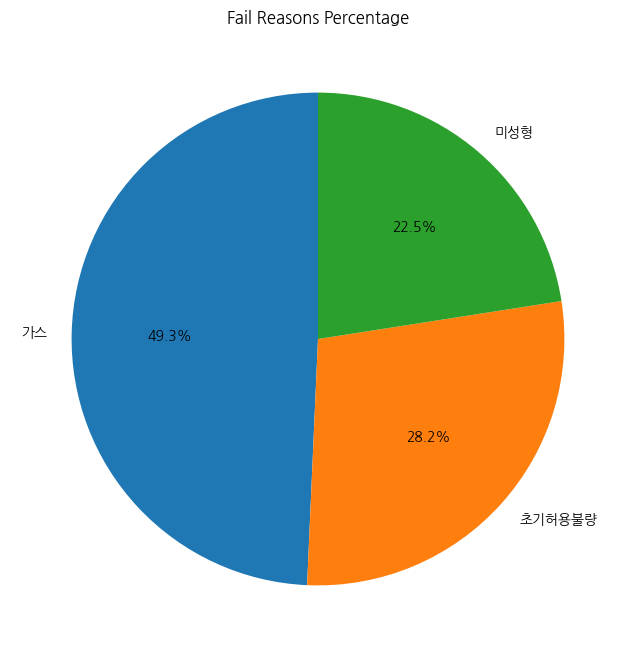

In [ ]:
# 데이터 준비
reason_counts = label_data[label_data['PassOrFail'] == 'N']['Reason'].value_counts(normalize=True).mul(100).round(2)

# 파이 차트 생성
plt.figure(figsize=(8,8)) # optional: 크기 조절
plt.pie(reason_counts, labels=reason_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Fail Reasons Percentage') # optional: 제목 추가
plt.show()

In [ ]:
def del_column(data, machine_name, product_name):
    machine = data['EQUIP_NAME'] == machine_name
    product = data['PART_NAME'] == product_name
    data = data[machine & product]

    # 불필요하다고 판단되는 컬럼들 및 0이 많은 컬럼들 제거
    data = data.drop(['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE',
                      'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME',
                      'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_5',
                      'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8',
                      'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11',
                      'Mold_Temperature_12', 'Barrel_Temperature_7', 'Switch_Over_Position'], axis=1)
    return data

In [ ]:
# 데이터 호기 종류
machine_name = '650톤-우진2호기'

# 데이터 제품 종류
product_name = ["CN7 W/S SIDE MLD'G LH", "CN7 W/S SIDE MLD'G RH",
                "RG3 MOLD'G W/SHLD, LH", "RG3 MOLD'G W/SHLD, RH"]

# '650톤-우진2호기'의 "CN7 W/S SIDE MLD'G LH" 데이터만 가져오기
cn7lh = del_column(label_data, machine_name, product_name[0])

# '650톤-우진2호기'의 "CN7 W/S SIDE MLD'G RH" 데이터만 가져오기
cn7rh = del_column(label_data, machine_name, product_name[1])

# '650톤-우진2호기'의 "RG3 MOLD'G W/SHLD, LH" 데이터만 가져오기
rg3lh = del_column(label_data, machine_name, product_name[2])

# '650톤-우진2호기'의 "RG3 MOLD'G W/SHLD, LH" 데이터만 가져오기
rg3rh = del_column(label_data, machine_name, product_name[3])

# 동일 제품의 LH와 RH 묶기
cn7 = pd.concat([cn7lh, cn7rh], ignore_index=True)
rg3 = pd.concat([rg3lh, rg3rh], ignore_index=True)

In [ ]:
# 데이터 저장
cn7.to_csv('labeled_cn7.csv', index=False)
rg3.to_csv('labeled_rg3.csv', index=False)

# cn7, rg3 서로 다른 차량이므로 나눠서 분석 진행.


In [ ]:
cn7 = pd.read_csv('/content/labeled_cn7.csv')
rg3 = pd.read_csv('/content/labeled_rg3.csv')

cn7['group'] = 'cn7'
rg3['group'] = 'rg3'

# 데이터 합치기
df = pd.concat([cn7, rg3], ignore_index=True)

# 데이터 저장
df.to_csv('labeled_concat.csv', index=False)

In [ ]:
# 보기 좋게 group을 앞으로 뺌
df = df[['group'] + [col for col in df.columns if col != 'group']]

df

,group,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,cn7,Y,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.600000
1,cn7,Y,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.600000
2,cn7,Y,NaN,9.58,4.46,16.90,59.580002,7.13,653.409973,68.839996,...,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.600000
3,cn7,Y,NaN,9.58,4.46,16.92,59.560001,7.13,653.409973,68.849998,...,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.600000
4,cn7,Y,NaN,9.57,4.45,16.91,59.520000,7.14,653.409973,68.830002,...,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7987,rg3,Y,NaN,1.07,0.94,13.06,61.779999,6.79,654.250000,53.610001,...,62.200001,285.600006,284.799988,285.399994,276.100006,265.399994,235.199997,64.400002,22.500000,24.200001
7988,rg3,Y,NaN,1.07,0.94,13.07,61.759998,6.79,654.260010,53.610001,...,61.900002,285.600006,285.100006,285.000000,275.799988,264.899994,235.100006,64.599998,22.400000,24.200001
7989,rg3,Y,NaN,1.07,0.94,13.09,61.740002,6.79,654.250000,53.619999,...,61.599998,286.200012,284.799988,285.100006,275.500000,265.000000,235.000000,63.000000,22.600000,24.400000
7990,rg3,Y,NaN,1.07,0.94,13.12,61.779999,6.79,654.250000,53.610001,...,61.500000,285.899994,284.899994,285.700012,274.899994,265.000000,234.899994,64.500000,22.500000,24.299999


클러스터링(K-means)

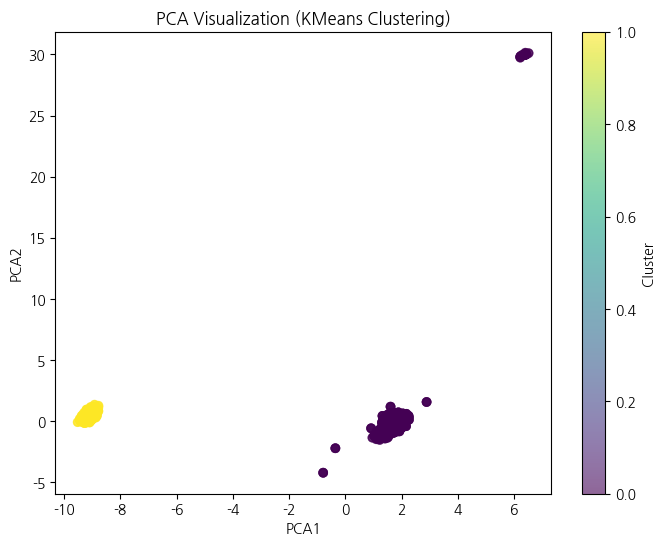

In [ ]:
# 1. 숫자형 데이터만 추출 (group, PassOrFail, Reason 제외)
X = df.drop(columns=['PassOrFail', 'Reason', 'group'])

# 2. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. KMeans 클러스터링 (k=2)
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 4. PCA로 2D 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.title('PCA Visualization (KMeans Clustering)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
# 실제 group vs 클러스터링 결과를 교차표로 비교하기
pd.crosstab(df['group'], df['cluster'])

cluster,0,1
group,,
cn7,6736,0
rg3,0,1256


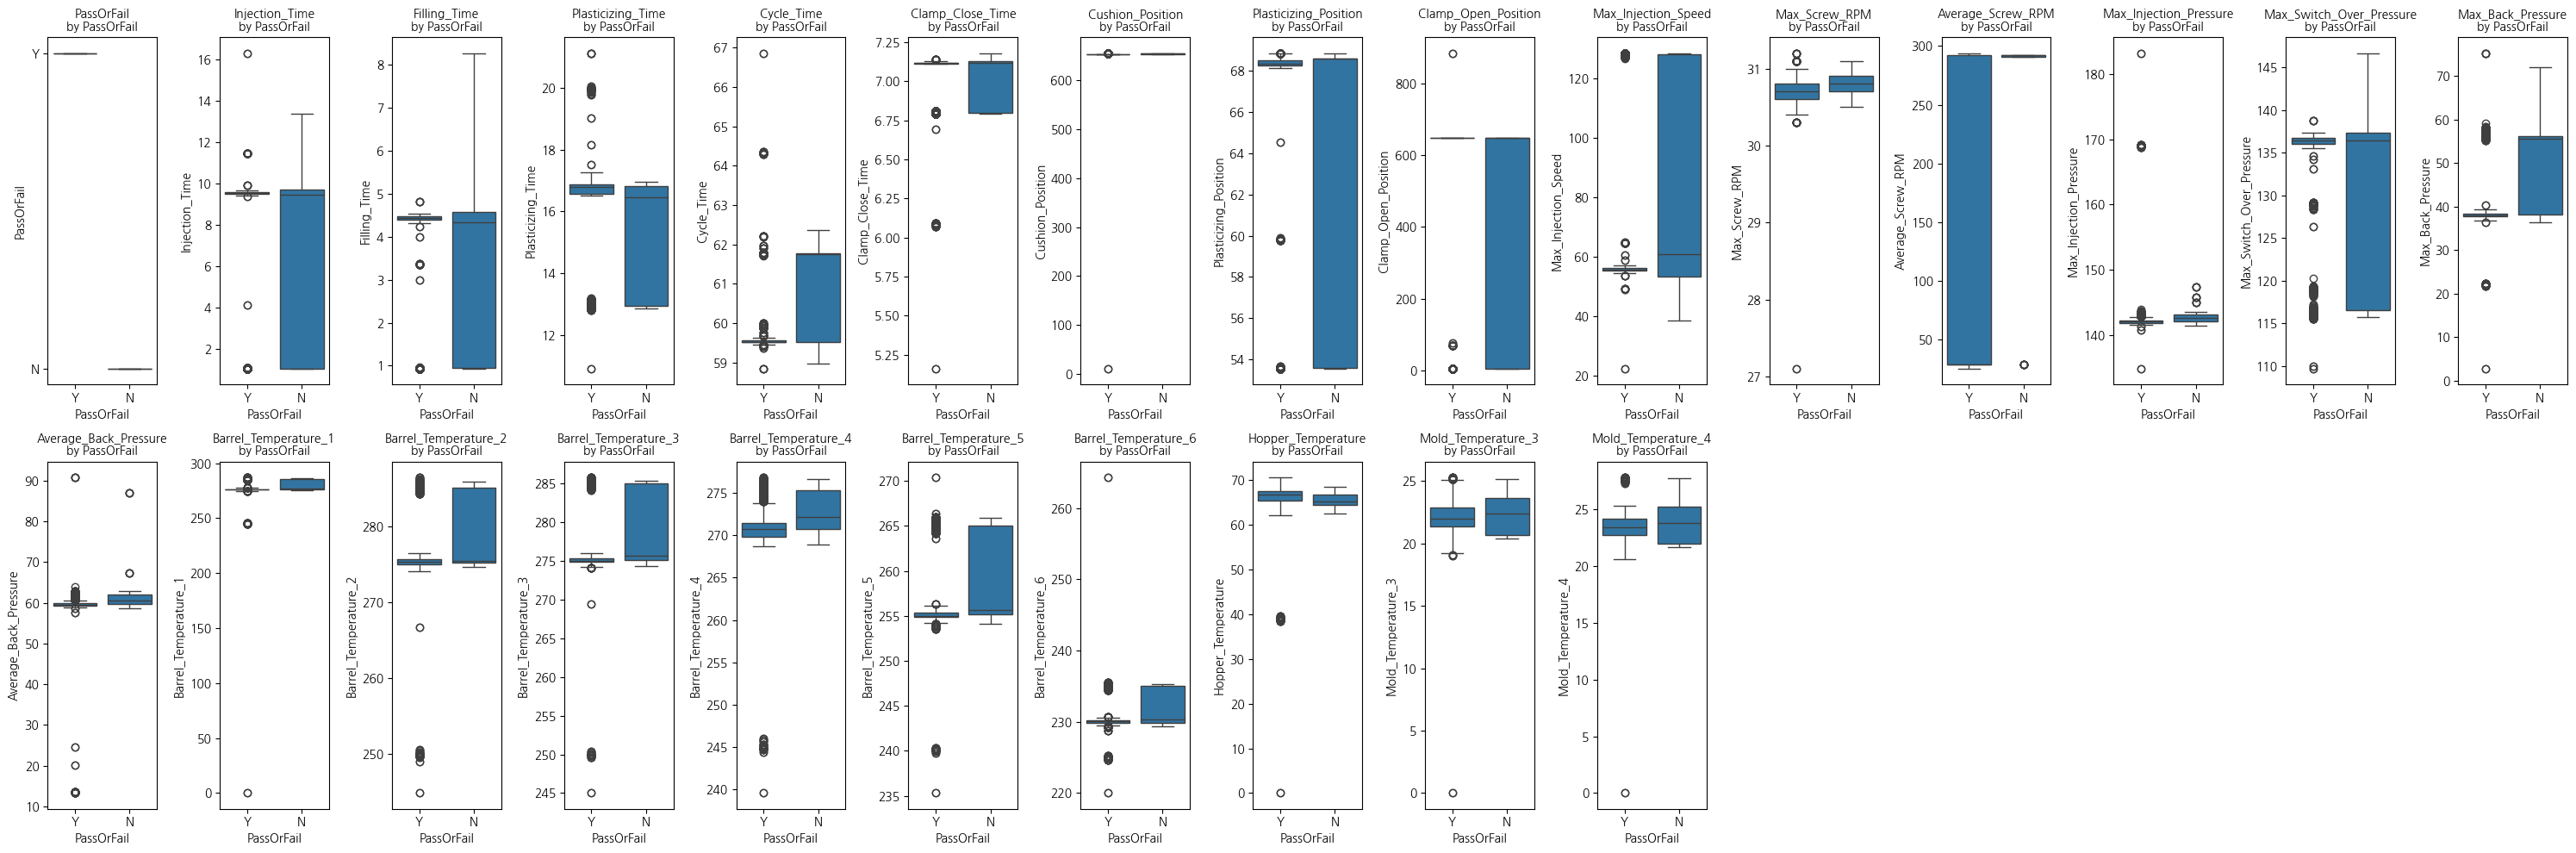

In [ ]:
columns_to_exclude = [
    '_id', 'TimeStamp', 'PART_FACT_PLAN_DATE',
    'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME',
    'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_5',
    'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8',
    'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11',
    'Mold_Temperature_12', 'Barrel_Temperature_7', 'Switch_Over_Position', 'Reason'
]

# 박스플롯을 그릴 컬럼 이름 리스트 (제외할 컬럼 제외)
columns_to_plot = [col for col in label_data.columns if col not in columns_to_exclude]

# 그래프를 그리기 위한 subplot 설정
num_cols = 15  # 한 줄에 15개씩 그래프를 배치
num_rows = (len(columns_to_plot) + num_cols - 1) // num_cols  # 전체 행 수 계산

# figsize 조정: 가로 크기를 늘림
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(30, 5 * num_rows))  # 가로 크기 20 -> 30으로 변경
axes = axes.flatten()  # 2차원 axes 배열을 1차원으로 펼쳐서 인덱싱하기 쉽게 만듦

# 각 컬럼에 대해 박스플롯 그리기
for i, column in enumerate(columns_to_plot):
    sns.boxplot(x='PassOrFail', y=column, data=label_data, ax=axes[i])
    axes[i].set_title(f'{column}\nby PassOrFail', fontsize=10)  # 제목 줄바꿈 및 폰트 크기 줄임
    # axes[i].set_title(f'{column} by PassOrFail', fontsize=8) # 폰트 사이즈만 줄이는 방법
    # axes[i].set_title(column[:20] + '\nby PassOrFail', fontsize=10)  # 컬럼 이름이 너무 길 경우, 처음 20글자만 표시하고 줄바꿈

# 빈 subplot 제거
for i in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[i])

# subplot 간 간격 조정: 가로 간격을 줄임
plt.subplots_adjust(wspace=0.3)  # 가로 간격을 0.4 -> 0.3으로 변경

# 그래프 간 간격 자동 조절
plt.tight_layout()
plt.show()

# cn7

In [ ]:
# 데이터 타입 확인
print(cn7['PassOrFail'].dtype)

# 문자열로 변환 (필요한 경우)
cn7['PassOrFail'] = cn7['PassOrFail'].astype(str)

# 'Y'를 0으로, 'N'을 1로 변경
cn7['PassOrFail'] = cn7['PassOrFail'].replace({'Y': 0, 'N': 1})

# 결과 확인
cn7

object


<ipython-input-19-2706ec48b8b3>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cn7['PassOrFail'] = cn7['PassOrFail'].replace({'Y': 0, 'N': 1})


,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,group
0,0,NaN,9.60,4.48,16.910000,59.580002,7.13,653.409973,68.839996,647.98999,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.600000,cn7
1,0,NaN,9.59,4.48,16.910000,59.560001,7.13,653.419983,68.839996,647.98999,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.600000,cn7
2,0,NaN,9.58,4.46,16.900000,59.580002,7.13,653.409973,68.839996,647.98999,...,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.600000,cn7
3,0,NaN,9.58,4.46,16.920000,59.560001,7.13,653.409973,68.849998,647.98999,...,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.600000,cn7
4,0,NaN,9.57,4.45,16.910000,59.520000,7.14,653.409973,68.830002,647.98999,...,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.500000,cn7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6731,0,NaN,9.58,4.46,16.670000,59.520000,7.11,653.429993,68.339996,647.98999,...,275.799988,275.500000,275.500000,269.500000,255.000000,230.199997,66.000000,21.000000,22.400000,cn7
6732,0,NaN,9.60,4.49,16.650000,59.540001,7.11,653.429993,68.320000,647.98999,...,276.100006,275.899994,274.899994,269.700012,254.600006,229.600006,65.400002,21.000000,22.400000,cn7
6733,0,NaN,9.60,4.48,16.620001,59.560001,7.11,653.429993,68.330002,647.98999,...,276.500000,274.899994,275.100006,269.500000,255.600006,229.600006,66.099998,21.000000,22.400000,cn7
6734,0,NaN,9.60,4.48,16.650000,59.560001,7.11,653.429993,68.349998,647.98999,...,275.799988,275.299988,275.500000,270.700012,254.899994,230.000000,66.099998,21.000000,22.400000,cn7


In [ ]:
# 스크류 단면적 (단위: cm²) - 제공된 값 사용
screw_cross_section_area_cm2 = 63.62

# 사출속도 (단위: mm/s) → cm/s로 변환
injection_speed_cm_per_s = cn7["Max_Injection_Speed"] / 10

# 사출률 계산: 단면적(cm²) × 속도(cm/s) = cm³/s
cn7["Injection_Rate_Calc"] = screw_cross_section_area_cm2 * injection_speed_cm_per_s

# 파생 변수 생성 -> Avg_Material_Temp
cn7['Avg_Material_Temp'] = (cn7['Hopper_Temperature'] + cn7['Barrel_Temperature_1']) / 2

# 몰드 온도 평균
cn7['Mean_Mold_Temp'] = (cn7['Mold_Temperature_3'] + cn7['Mold_Temperature_4']) / 2

#  시간 비율
cn7['Filling_Ratio'] = cn7['Filling_Time'] / cn7['Injection_Time']

# 백압 vs. 인젝션 압력 차이
cn7['Avg_Back_Pressure_Ratio'] = cn7['Average_Back_Pressure'] / cn7['Max_Back_Pressure']

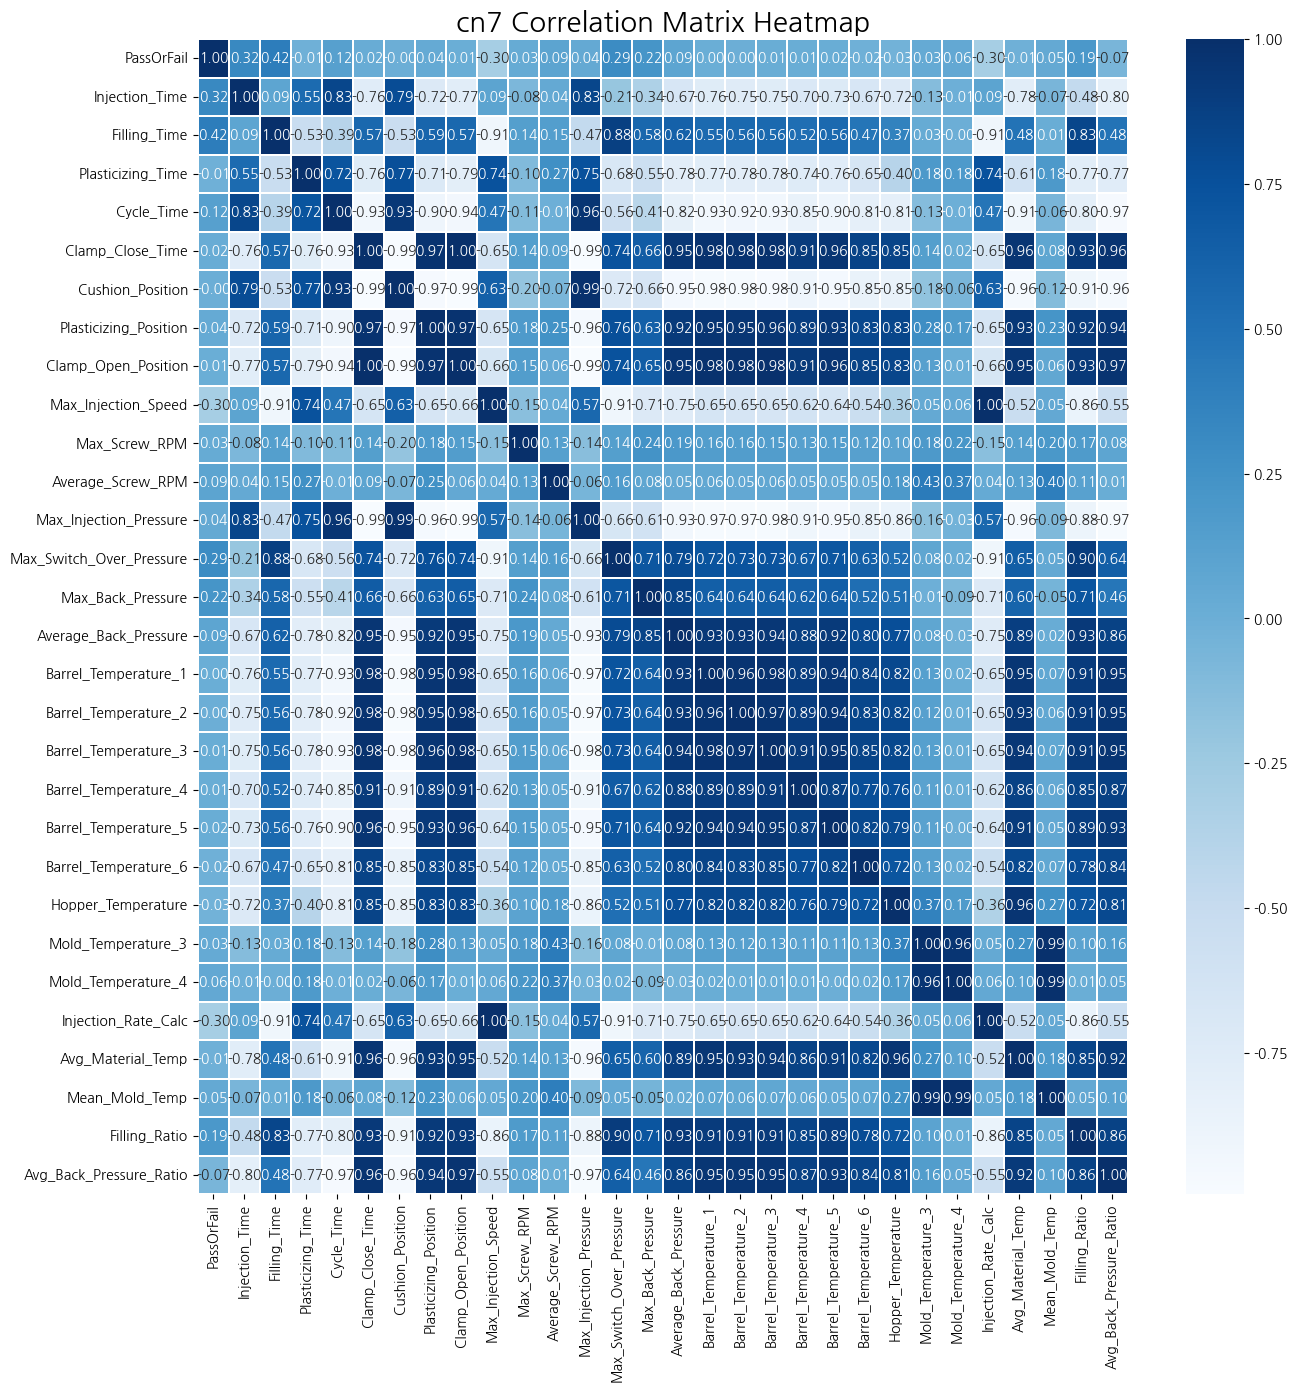

In [ ]:
# 수치형 컬럼만 선택
numeric_df = cn7.select_dtypes(include='number')

# 상관계수 계산
correlation_matrix = numeric_df.corr()

# 상관계수 히트맵 그리기
plt.subplots(figsize=(15, 15))  # 크기 조정
sns.heatmap(data=correlation_matrix, linewidths=0.1, annot=True, fmt='.2f', cmap='Blues')
plt.title('cn7 Correlation Matrix Heatmap', fontsize=20)
plt.show()

## 불량일때 reason 분포

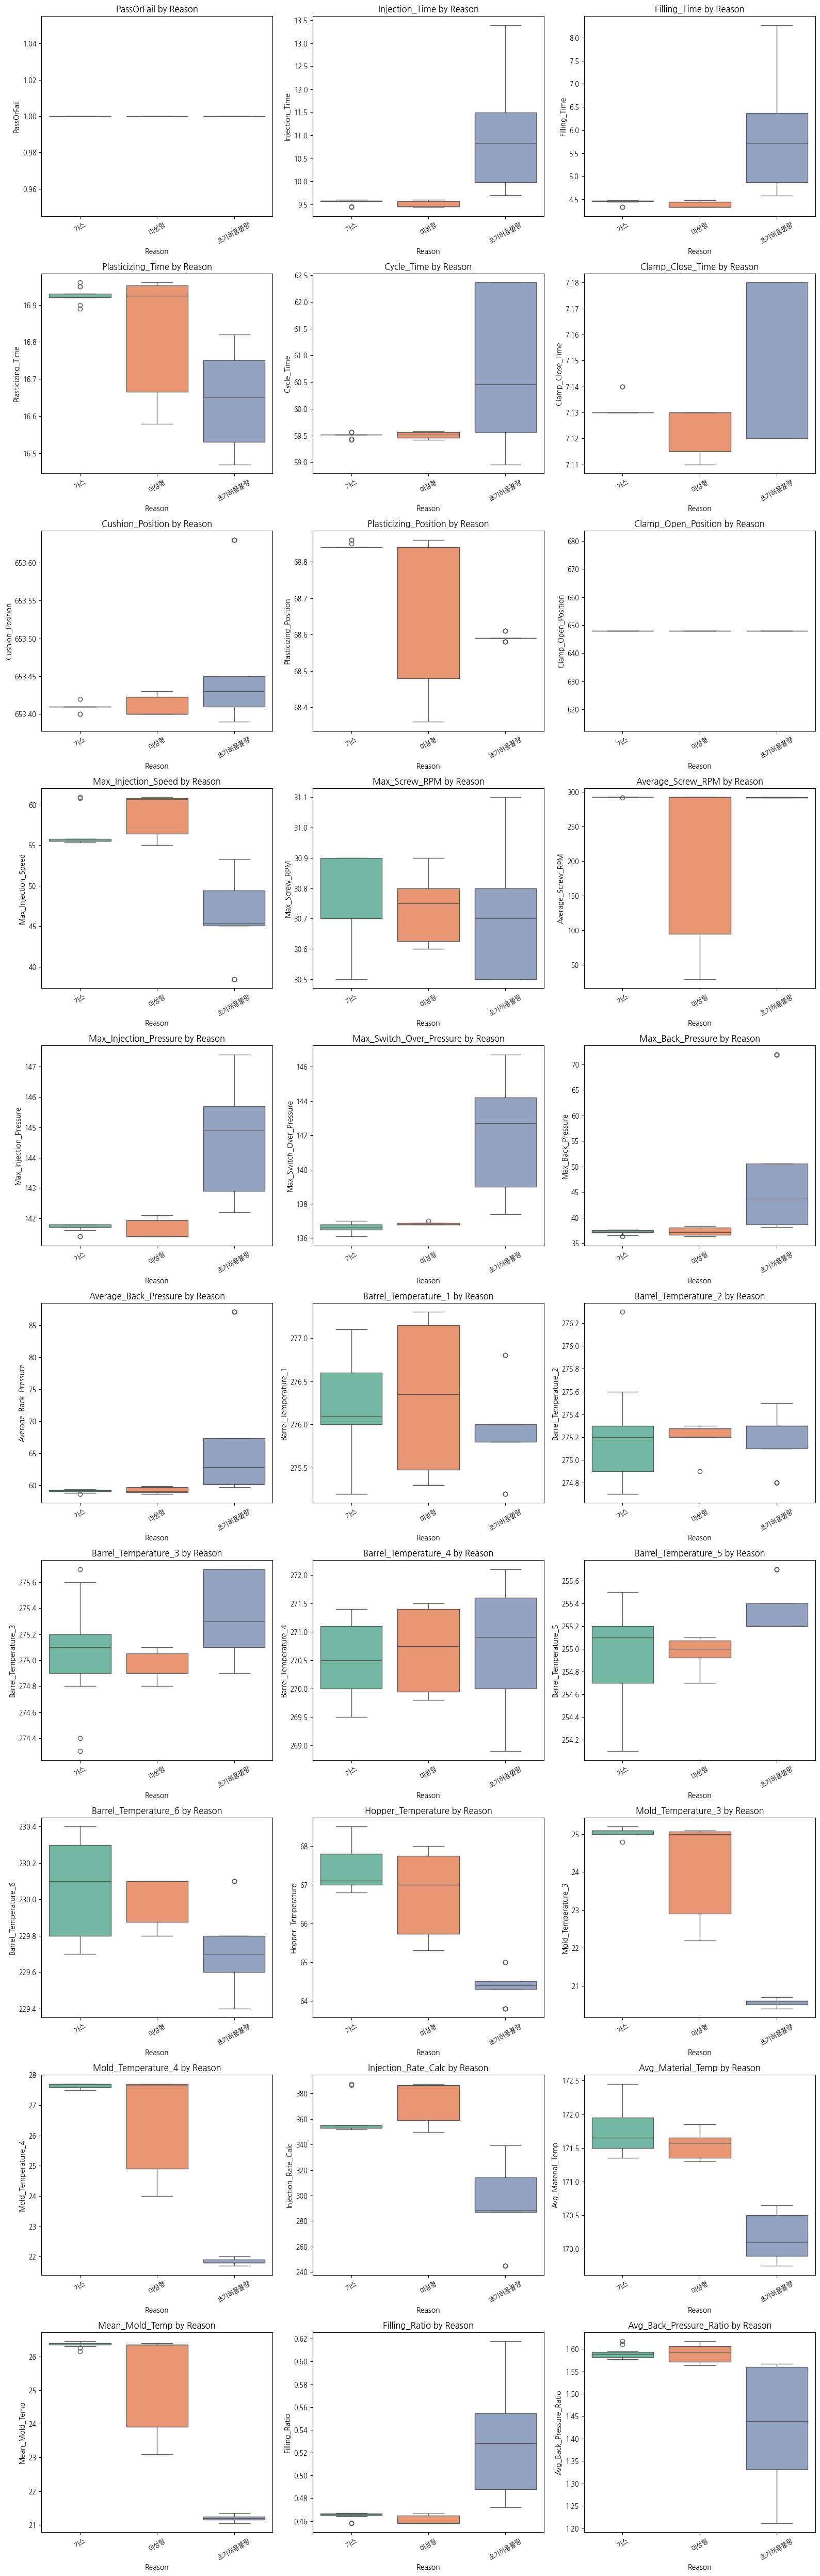

In [ ]:
# 수치형 컬럼만 선택 (PassOrFail 제외 가능)
numeric_columns = cn7.select_dtypes(include=['number']).columns

# 상위 5개 불량 원인만 시각화
top_reasons = cn7["Reason"].value_counts().head(5).index.tolist()
cn7_reason = cn7[cn7["Reason"].isin(top_reasons)]

# 그래프 구성
cols_per_row = 3
rows = int(np.ceil(len(numeric_columns) / cols_per_row))

plt.figure(figsize=(16, 5 * rows))
for i, col in enumerate(numeric_columns):
    plt.subplot(rows, cols_per_row, i + 1)
    sns.boxplot(data=cn7_reason, x='Reason', y=col, hue='Reason', palette='Set2', legend=False)
    plt.title(f'{col} by Reason', fontsize=12)
    plt.xlabel('Reason', fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.xticks(rotation=30, fontsize=9)
    plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()


### 양품과 불량품 간의 분포 차이(cn7만)

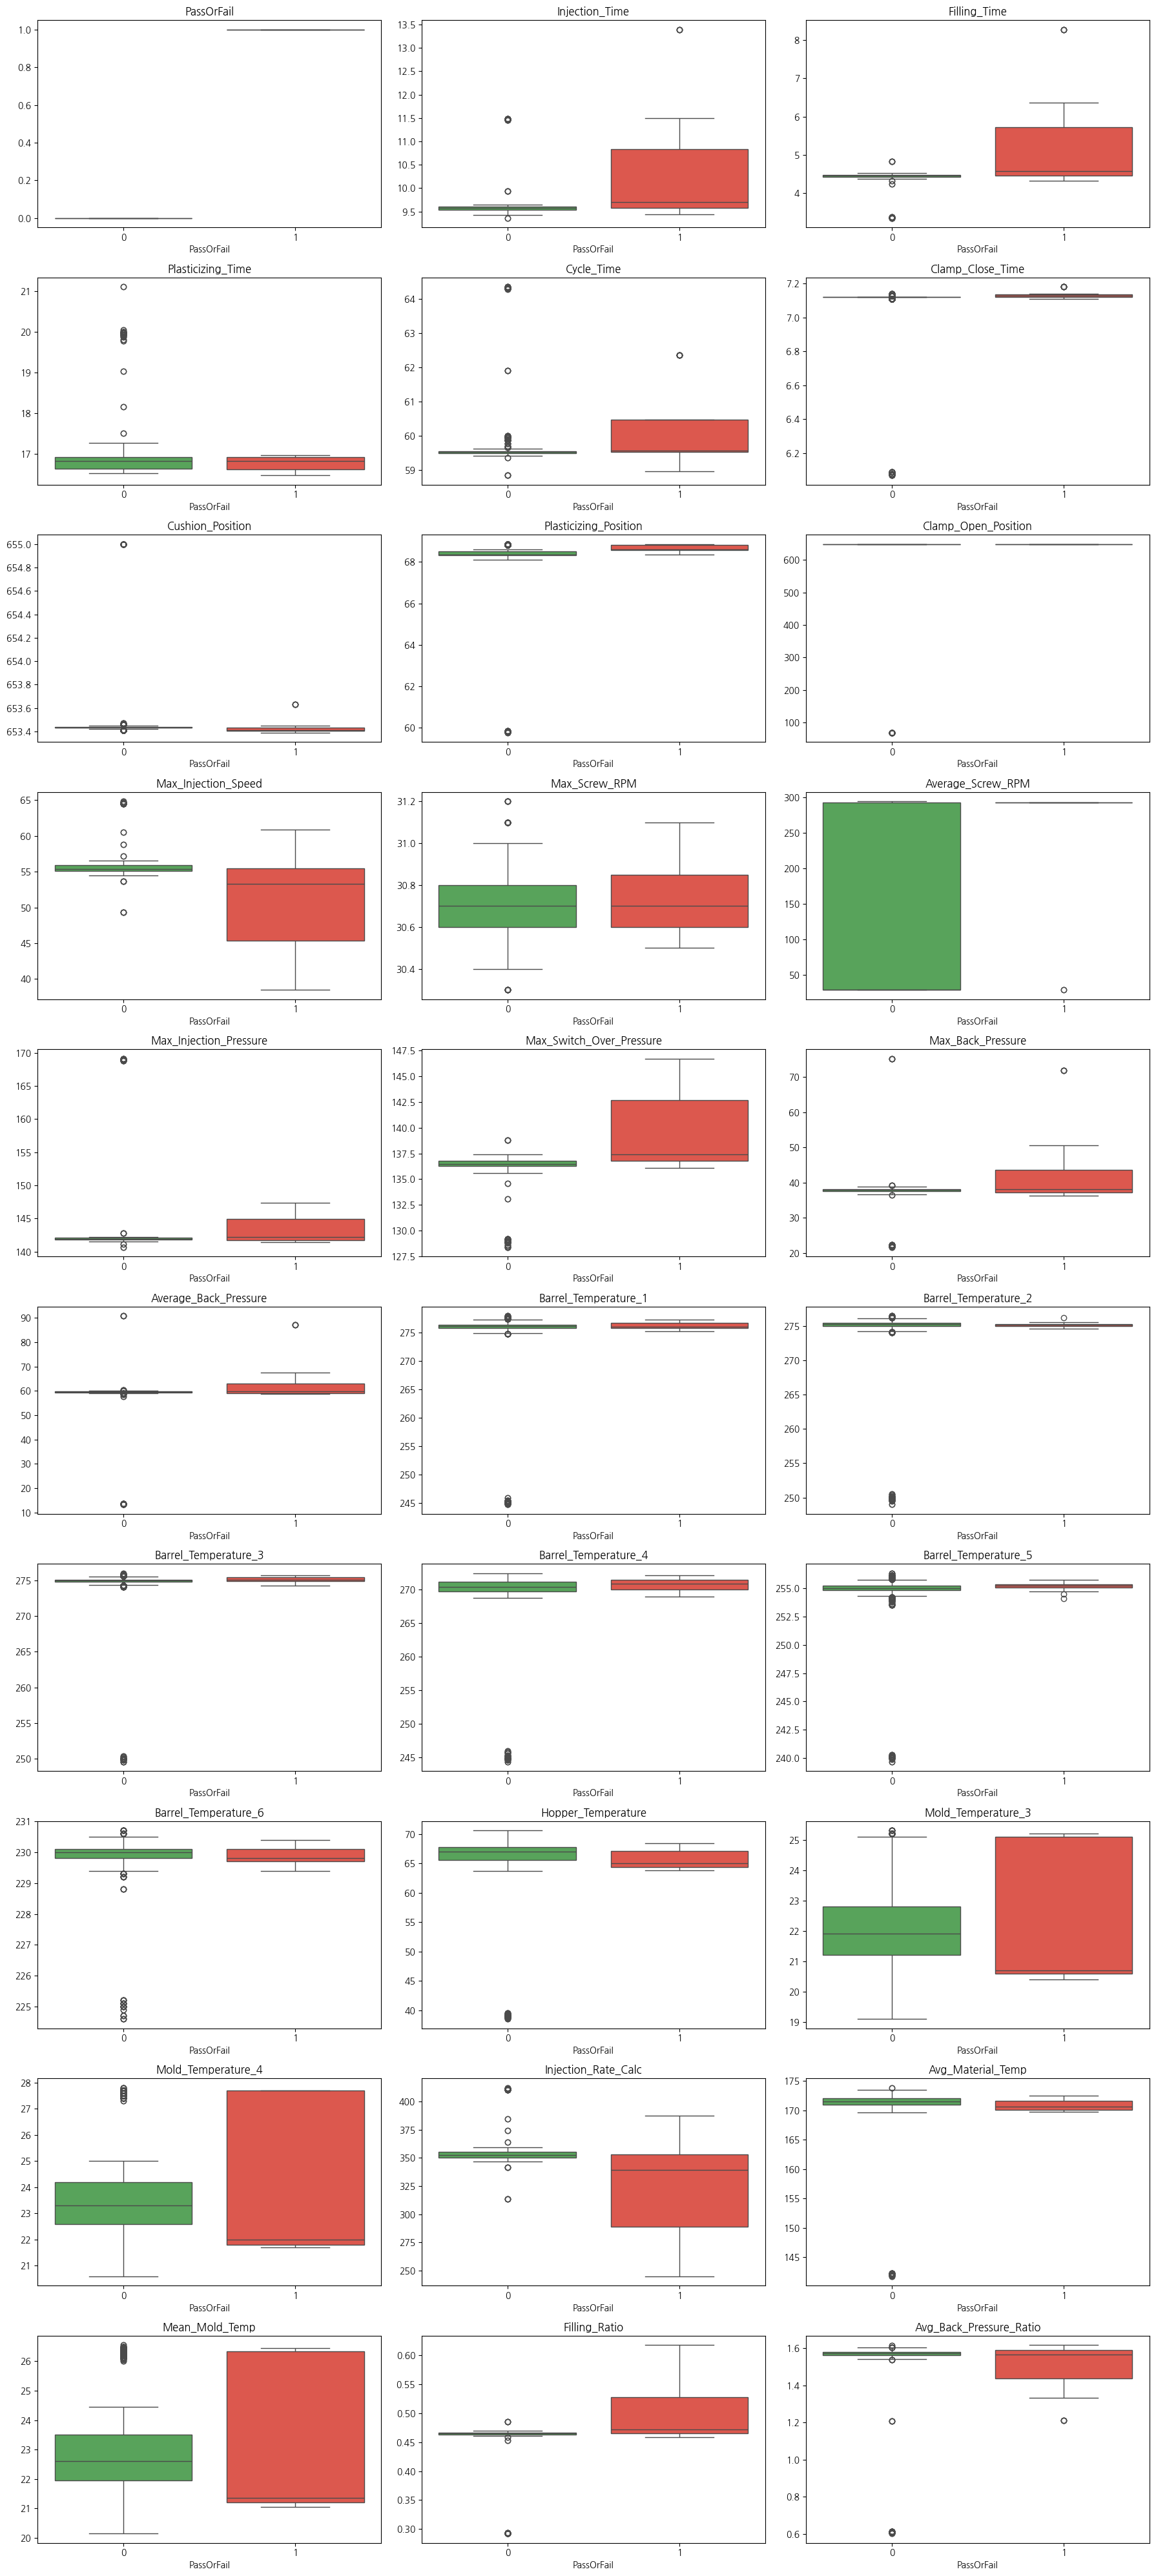

In [ ]:
# 수치형 컬럼만 선택
numeric_cols = cn7.select_dtypes(include=['float64', 'int64']).columns

# 한 줄에 3개씩 배치
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# 그래프 크기 설정
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*4))

# 색상 설정
palette = {'0': '#4CAF50', '1': '#F44336'}

# 각 컬럼별 박스 플롯 그리기
for idx, col in enumerate(numeric_cols):
    row, col_idx = divmod(idx, n_cols)
    sns.boxplot(x=cn7['PassOrFail'].astype(str), y=col, hue=cn7['PassOrFail'].astype(str),
                data=cn7, ax=axes[row, col_idx], palette=palette, legend=False)
    axes[row, col_idx].set_title(f'{col}', fontsize=12)
    axes[row, col_idx].set_xlabel('PassOrFail')
    axes[row, col_idx].set_ylabel('')

# 남는 빈 그래프 제거
for idx in range(len(numeric_cols), n_rows*n_cols):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()

다중공선성 처리하여 최종 컬럼 선정

In [ ]:
# 원하는 컬럼만 선택
selected_columns = ['PassOrFail', 'Injection_Time', 'Plasticizing_Time', 'Cycle_Time',
                    'Average_Screw_RPM', 'Max_Switch_Over_Pressure', 'Average_Back_Pressure',
                    'Mold_Temperature_4', 'Injection_Rate_Calc', 'Avg_Material_Temp']

cn7_reduced = cn7[selected_columns]

# 새로운 파일로 저장
cn7_reduced.to_csv("cn7_reduced.csv", index=False)


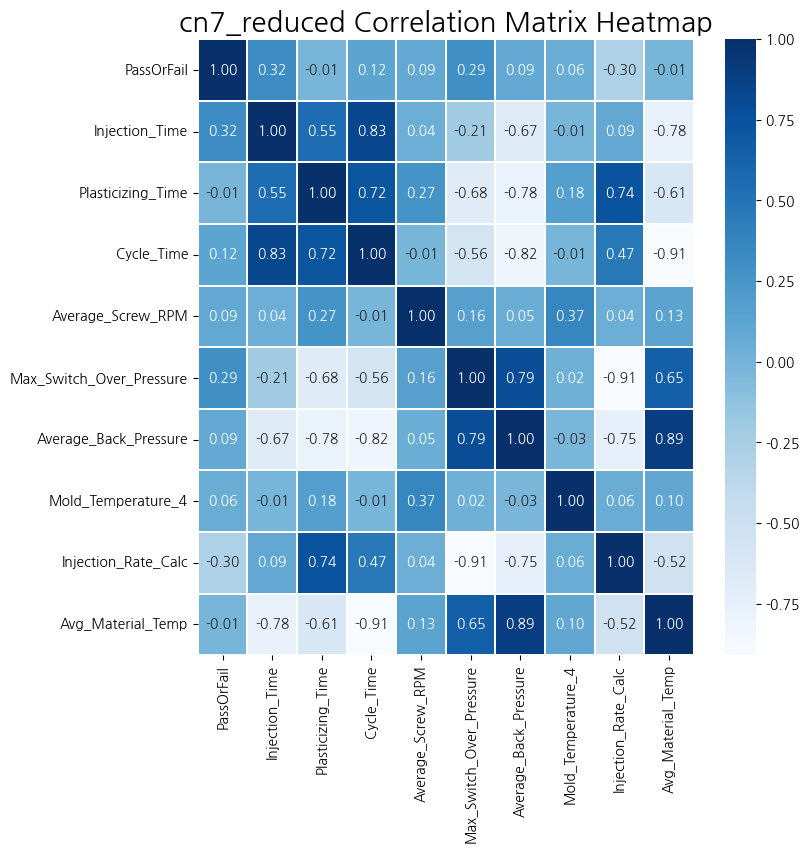

In [ ]:
# 수치형 컬럼만 선택
numeric_df = cn7_reduced.select_dtypes(include='number')

# 상관계수 계산
correlation_matrix = numeric_df.corr()

# 상관계수 히트맵 그리기
plt.subplots(figsize=(8, 8))  # 크기 조정
sns.heatmap(data=correlation_matrix, linewidths=0.1, annot=True, fmt='.2f', cmap='Blues')
plt.title('cn7_reduced Correlation Matrix Heatmap', fontsize=20)
plt.show()

머신러닝 (XGB)

In [ ]:
# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Injection_Time', 'Plasticizing_Time', 'Cycle_Time',
            'Average_Screw_RPM', 'Max_Switch_Over_Pressure',
            'Average_Back_Pressure', 'Mold_Temperature_4', 'Injection_Rate_Calc',
            'Avg_Material_Temp']

X = cn7_reduced[features]
y = cn7_reduced[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# y값 타입 변환 (문자열 → 정수)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# XGBoost 모델 훈련
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, max_depth=5)
xgb_model.fit(X_train, y_train)

# 예측
y_pred_xgb = xgb_model.predict(X_test)

# 정확도 및 F1 점수 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted'))

# 분류 보고서 출력
print("🔹 XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

🔹 XGBoost Accuracy: 0.997624703087886
🔹 XGBoost F1 Score: 0.9974856885723773
🔹 XGBoost Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3349
           1       0.87      0.68      0.76        19

    accuracy                           1.00      3368
   macro avg       0.93      0.84      0.88      3368
weighted avg       1.00      1.00      1.00      3368



머신러닝 (SVM)

In [ ]:
# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Injection_Time', 'Plasticizing_Time', 'Cycle_Time',
            'Average_Screw_RPM', 'Max_Switch_Over_Pressure',
            'Average_Back_Pressure', 'Mold_Temperature_4', 'Injection_Rate_Calc',
            'Avg_Material_Temp']

X = cn7_reduced[features]
y = cn7_reduced[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# 데이터 정규화 및 SVM 모델 생성
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# 모델 학습
svm_model.fit(X_train, y_train)

# 예측 수행
y_pred = svm_model.predict(X_test)

# SVM 모델 훈련 및 평가
# SVM은 데이터 스케일링에 민감하므로 StandardScaler를 사용하여 스케일링합니다.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("🔹 SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("🔹 SVM F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))
print("🔹 SVM Report:\n", classification_report(y_test, y_pred_svm))

🔹 SVM Accuracy: 0.997624703087886
🔹 SVM F1 Score: 0.9973094136518531
🔹 SVM Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3349
           1       1.00      0.58      0.73        19

    accuracy                           1.00      3368
   macro avg       1.00      0.79      0.87      3368
weighted avg       1.00      1.00      1.00      3368



머신러닝 (RF)

In [ ]:
# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Injection_Time', 'Plasticizing_Time', 'Cycle_Time',
            'Average_Screw_RPM', 'Max_Switch_Over_Pressure',
            'Average_Back_Pressure', 'Mold_Temperature_4', 'Injection_Rate_Calc',
            'Avg_Material_Temp']

X = cn7_reduced[features]
y = cn7_reduced[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# Random Forest 모델 훈련
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# 예측
y_pred_rf = rf_model.predict(X_test)

# 평가
print("🔹 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("🔹 Random Forest F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))
print("🔹 Random Forest Report:\n", classification_report(y_test, y_pred_rf))


🔹 Random Forest Accuracy: 0.998812351543943
🔹 Random Forest F1 Score: 0.9987428442861885
🔹 Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3349
           1       1.00      0.79      0.88        19

    accuracy                           1.00      3368
   macro avg       1.00      0.89      0.94      3368
weighted avg       1.00      1.00      1.00      3368



이상탐지하여 머신러닝 다시 진행 (XGB)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.2904 - val_loss: 0.8974
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2844 - val_loss: 0.8920
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2775 - val_loss: 0.8856
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2685 - val_loss: 0.8785
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2595 - val_loss: 0.8724
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2529 - val_loss: 0.8672
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.2476 - val_loss: 0.8623
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2428 - val_loss: 0.8574
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.2380 - val_loss: 0.8524
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2332 - val_loss: 0.8473
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.2283 - val_loss: 0.8422
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.223

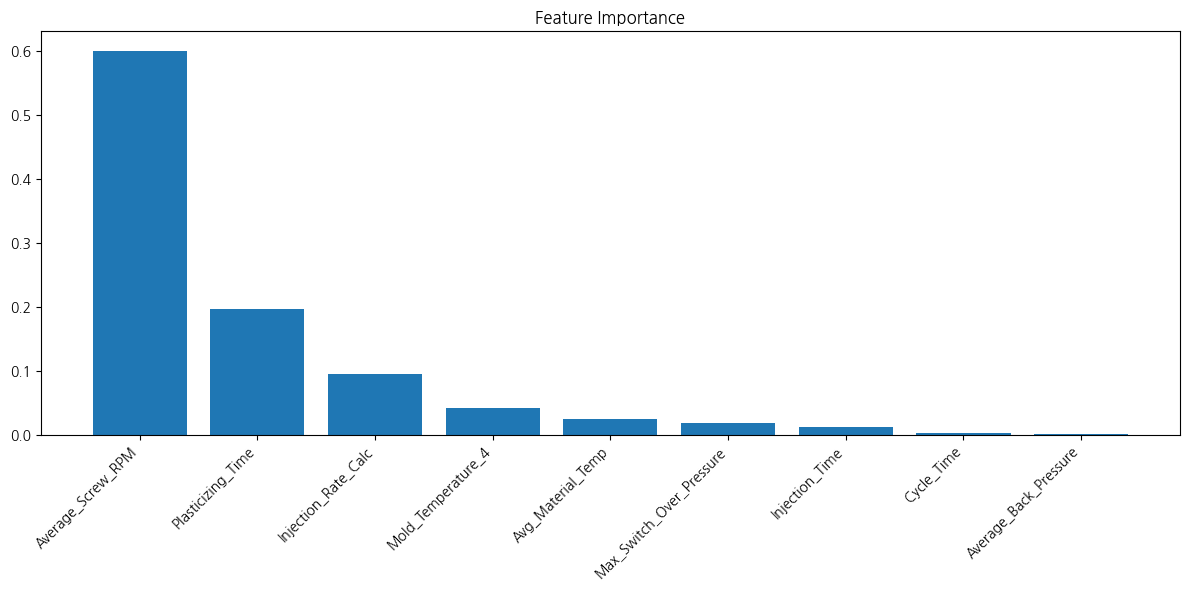


🔹 Feature Importance:
                    Feature  Importance
0         Average_Screw_RPM    0.601243
1         Plasticizing_Time    0.197629
2       Injection_Rate_Calc    0.095503
3        Mold_Temperature_4    0.043112
4         Avg_Material_Temp    0.025831
5  Max_Switch_Over_Pressure    0.018341
6            Injection_Time    0.012906
7                Cycle_Time    0.003797
8     Average_Back_Pressure    0.001637

🔹 Feature Importances:
                    Feature  Importance
0         Average_Screw_RPM    0.601243
1         Plasticizing_Time    0.197629
2       Injection_Rate_Calc    0.095503
3        Mold_Temperature_4    0.043112
4         Avg_Material_Temp    0.025831
5  Max_Switch_Over_Pressure    0.018341
6            Injection_Time    0.012906
7                Cycle_Time    0.003797
8     Average_Back_Pressure    0.001637

🔹 Feature importances saved to xgboost_feature_importances.pkl
✅ Train Accuracy: 0.9474
✅ Test Accuracy: 0.9474
과적합이 의심되지 않습니다.


In [ ]:
# 데이터 전처리
# 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Injection_Time', 'Plasticizing_Time', 'Cycle_Time',
            'Average_Screw_RPM', 'Max_Switch_Over_Pressure',
            'Average_Back_Pressure', 'Mold_Temperature_4', 'Injection_Rate_Calc',
            'Avg_Material_Temp']

X = cn7_reduced[features]
y = cn7_reduced[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Autoencoder 모델 정의
input_dim = X_train_scaled.shape[1]
encoding_dim = 2  # 인코딩 차원

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# 2. Autoencoder 모델 학습
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=50, batch_size=256, validation_split=0.2)

# 3. 재구성 오류 계산
X_train_pred = autoencoder.predict(X_train_scaled)
X_test_pred = autoencoder.predict(X_test_scaled)

train_loss = np.mean(np.square(X_train_scaled - X_train_pred), axis=1)
test_loss = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

# 4. 이상치 탐지: 재구성 오류 임계값 설정
threshold = np.percentile(train_loss, 85)  # 상위 15%를 이상치로 간주

# 이상치 예측
train_outliers = train_loss > threshold
test_outliers = test_loss > threshold

# 5. 데이터 정제: 불량 데이터 유지
X_train_cleaned = X_train[~train_outliers | (y_train == 1)]
y_train_cleaned = y_train[~train_outliers | (y_train == 1)]

X_test_cleaned = X_test[~test_outliers | (y_test == 1)]
y_test_cleaned = y_test[~test_outliers | (y_test == 1)]

# 6. SMOTE를 사용하여 불량 데이터 오버샘플링
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_cleaned, y_train_cleaned)

# 7. XGBoost 모델 훈련

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, max_depth=5)
xgb_model.fit(X_resampled, y_resampled)

# 8. 예측
y_pred_xgb = xgb_model.predict(X_test_cleaned)

# 9. 정확도 및 F1 점수 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test_cleaned, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test_cleaned, y_pred_xgb, average='weighted'))

# 10. 분류 보고서 출력
print("🔹 XGBoost Report:\n", classification_report(y_test_cleaned, y_pred_xgb))

# 11. Feature Importance 시각화
feature_importances = xgb_model.feature_importances_
feature_names = X.columns  # 원본 feature 이름 사용

# 중요도 내림차순으로 정렬
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importance")
plt.bar(range(len(feature_names)), feature_importances[indices], align="center")
plt.xticks(range(len(feature_names)), feature_names[indices], rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Feature Importance를 DataFrame으로 만들어 출력
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
print("\n🔹 Feature Importance:")
print(feature_importance_df)

# 12. XGBoost 모델 가중치 저장
importances = xgb_model.feature_importances_
feature_importances = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importances = feature_importances.sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n🔹 Feature Importances:")
print(feature_importances)

# 가중치 파일로 저장 (예: 피클 파일)
with open("xgboost_feature_importances.pkl", "wb") as f:
    pickle.dump(feature_importances, f)

print("\n🔹 Feature importances saved to xgboost_feature_importances.pkl")

train_acc = xgb_model.score(X_train, y_train)  # 훈련 데이터 정확도
test_acc = xgb_model.score(X_test, y_test)  # 테스트 데이터 정확도

print(f"✅ Train Accuracy: {train_acc:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")

# 과적합 여부 확인
if train_acc - test_acc > 0.1:  # 임계값 조정 가능
    print("과적합이 의심됩니다.")
else:
    print("과적합이 의심되지 않습니다.")

이상탐지하여 머신러닝 다시 진행 (RF)

In [ ]:
# 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Injection_Time', 'Plasticizing_Time', 'Cycle_Time',
            'Average_Screw_RPM', 'Max_Switch_Over_Pressure',
            'Average_Back_Pressure', 'Mold_Temperature_4', 'Injection_Rate_Calc',
            'Avg_Material_Temp']

X = cn7_reduced[features]
y = cn7_reduced[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Autoencoder 모델 정의
input_dim = X_train_scaled.shape[1]
encoding_dim = 2  # 인코딩 차원

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# 2. Autoencoder 모델 학습
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=50, batch_size=256, validation_split=0.2, verbose=0)

# 3. 재구성 오류 계산
X_train_pred = autoencoder.predict(X_train_scaled)
X_test_pred = autoencoder.predict(X_test_scaled)

train_loss = np.mean(np.square(X_train_scaled - X_train_pred), axis=1)
test_loss = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

# 4. 이상치 탐지: 재구성 오류 임계값 설정
threshold = np.percentile(train_loss, 95)  # 상위 5%를 이상치로 간주

# 이상치 예측
train_outliers = train_loss > threshold
test_outliers = test_loss > threshold

# 5. 데이터 정제: 불량 데이터 유지
X_train_cleaned = X_train[~train_outliers | (y_train == 1)]
y_train_cleaned = y_train[~train_outliers | (y_train == 1)]

X_test_cleaned = X_test[~test_outliers | (y_test == 1)]
y_test_cleaned = y_test[~test_outliers | (y_test == 1)]

# 6. SMOTE를 사용하여 불량 데이터 오버샘플링
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_cleaned, y_train_cleaned)

# 7. Random Forest 모델 훈련 및 평가
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_resampled, y_resampled)
y_pred_rf = rf_model.predict(X_test_cleaned)

print("\n🔹 Random Forest Accuracy:", accuracy_score(y_test_cleaned, y_pred_rf))
print("🔹 Random Forest F1 Score:", f1_score(y_test_cleaned, y_pred_rf, average='weighted'))
print("🔹 Random Forest Report:\n", classification_report(y_test_cleaned, y_pred_rf))

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

🔹 Random Forest Accuracy: 0.9981504315659679
🔹 Random Forest F1 Score: 0.998042206576937
🔹 Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3225
           1       0.93      0.74      0.82        19

    accuracy                           1.00      3244
   macro avg       0.97      0.87      0.91      3244
weighted avg       1.00      1.00      1.00      3244



이상탐지하여 머신러닝 다시 진행 (SVM)

In [ ]:
# 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Injection_Time', 'Plasticizing_Time', 'Cycle_Time',
            'Average_Screw_RPM', 'Max_Switch_Over_Pressure',
            'Average_Back_Pressure', 'Mold_Temperature_4', 'Injection_Rate_Calc',
            'Avg_Material_Temp']

X = cn7_reduced[features]
y = cn7_reduced[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Autoencoder 모델 정의
input_dim = X_train_scaled.shape[1]
encoding_dim = 2  # 인코딩 차원

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# 2. Autoencoder 모델 학습
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=50, batch_size=256, validation_split=0.2, verbose=0)

# 3. 재구성 오류 계산
X_train_pred = autoencoder.predict(X_train_scaled)
X_test_pred = autoencoder.predict(X_test_scaled)

train_loss = np.mean(np.square(X_train_scaled - X_train_pred), axis=1)
test_loss = np.mean(np.square(X_test_scaled - X_test_pred), axis=1)

# 4. 이상치 탐지: 재구성 오류 임계값 설정
threshold = np.percentile(train_loss, 95)  # 상위 5%를 이상치로 간주

# 이상치 예측
train_outliers = train_loss > threshold
test_outliers = test_loss > threshold

# 5. 데이터 정제: 불량 데이터 유지
X_train_cleaned = X_train[~train_outliers | (y_train == 1)]
y_train_cleaned = y_train[~train_outliers | (y_train == 1)]

X_test_cleaned = X_test[~test_outliers | (y_test == 1)]
y_test_cleaned = y_test[~test_outliers | (y_test == 1)]

# 6. SMOTE를 사용하여 불량 데이터 오버샘플링
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_cleaned, y_train_cleaned)

# 7. SVM 모델 훈련 및 평가
svm_model = SVC(random_state=42)
svm_model.fit(X_resampled, y_resampled)
y_pred_svm = svm_model.predict(X_test_cleaned)

print("\n🔹 SVM Accuracy:", accuracy_score(y_test_cleaned, y_pred_svm))
print("🔹 SVM F1 Score:", f1_score(y_test_cleaned, y_pred_svm, average='weighted'))
print("🔹 SVM Report:\n", classification_report(y_test_cleaned, y_pred_svm))

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

🔹 SVM Accuracy: 0.6530989824236818
🔹 SVM F1 Score: 0.7842239066648372
🔹 SVM Report:
               precision    recall  f1-score   support

           0       1.00      0.65      0.79      3224
           1       0.02      1.00      0.03        19

    accuracy                           0.65      3243
   macro avg       0.51      0.83      0.41      3243
weighted avg       0.99      0.65      0.78      3243



## XGB로 최종 모델 선정. 과적합 확인

In [ ]:
train_acc = xgb_model.score(X_train, y_train)  # 훈련 데이터 정확도
test_acc = xgb_model.score(X_test, y_test)  # 테스트 데이터 정확도

print(f"✅ Train Accuracy: {train_acc:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")

# 과적합 여부 확인
if train_acc - test_acc > 0.1:  # 임계값 조정 가능
    print("과적합이 의심됩니다.")
else:
    print("과적합이 의심되지 않습니다.")

✅ Train Accuracy: 0.9474
✅ Test Accuracy: 0.9474
과적합이 의심되지 않습니다.


# rg3

In [ ]:
# 데이터 타입 확인
print(rg3['PassOrFail'].dtype)

# 문자열로 변환 (필요한 경우)
rg3['PassOrFail'] = rg3['PassOrFail'].astype(str)

# 'Y'를 0으로, 'N'을 1로 변경
rg3['PassOrFail'] = rg3['PassOrFail'].replace({'Y': 0, 'N': 1})

# 결과 확인
rg3

object


<ipython-input-33-444849fbdc01>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rg3['PassOrFail'] = rg3['PassOrFail'].replace({'Y': 0, 'N': 1})


,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,group
0,0,NaN,1.06,0.93,13.01,61.779999,6.81,654.289978,53.560001,4.63,...,286.000000,285.000000,285.000000,275.399994,265.100006,234.899994,65.800003,21.600000,22.500000,rg3
1,0,NaN,1.06,0.93,12.99,61.779999,6.81,654.280029,53.580002,4.63,...,286.200012,285.799988,285.000000,275.600006,265.600006,234.800003,65.800003,21.500000,22.500000,rg3
2,0,NaN,1.06,0.93,12.95,61.759998,6.81,654.270020,53.560001,4.63,...,286.500000,285.100006,285.000000,276.000000,265.100006,234.699997,65.900002,21.500000,22.500000,rg3
3,0,NaN,1.06,0.93,13.02,61.779999,6.81,654.270020,53.560001,4.63,...,285.299988,285.500000,284.500000,276.000000,264.799988,234.800003,65.900002,21.600000,22.500000,rg3
4,0,NaN,1.06,0.93,12.97,61.779999,6.81,654.280029,53.560001,4.63,...,286.299988,285.899994,285.600006,275.399994,265.000000,235.199997,65.800003,21.600000,22.500000,rg3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,0,NaN,1.07,0.94,13.06,61.779999,6.79,654.250000,53.610001,4.63,...,285.600006,284.799988,285.399994,276.100006,265.399994,235.199997,64.400002,22.500000,24.200001,rg3
1252,0,NaN,1.07,0.94,13.07,61.759998,6.79,654.260010,53.610001,4.63,...,285.600006,285.100006,285.000000,275.799988,264.899994,235.100006,64.599998,22.400000,24.200001,rg3
1253,0,NaN,1.07,0.94,13.09,61.740002,6.79,654.250000,53.619999,4.63,...,286.200012,284.799988,285.100006,275.500000,265.000000,235.000000,63.000000,22.600000,24.400000,rg3
1254,0,NaN,1.07,0.94,13.12,61.779999,6.79,654.250000,53.610001,4.63,...,285.899994,284.899994,285.700012,274.899994,265.000000,234.899994,64.500000,22.500000,24.299999,rg3


In [ ]:
# 스크류 단면적 (단위: cm²) - 제공된 값 사용
screw_cross_section_area_cm2 = 63.62

# 사출속도 (단위: mm/s) → cm/s로 변환
injection_speed_cm_per_s = rg3["Max_Injection_Speed"] / 10

# 사출률 계산: 단면적(cm²) × 속도(cm/s) = cm³/s
rg3["Injection_Rate_Calc"] = screw_cross_section_area_cm2 * injection_speed_cm_per_s

rg3['Avg_Material_Temp'] = (rg3['Hopper_Temperature'] + rg3['Barrel_Temperature_1']) / 2

## 불량품일 때 원인 분포

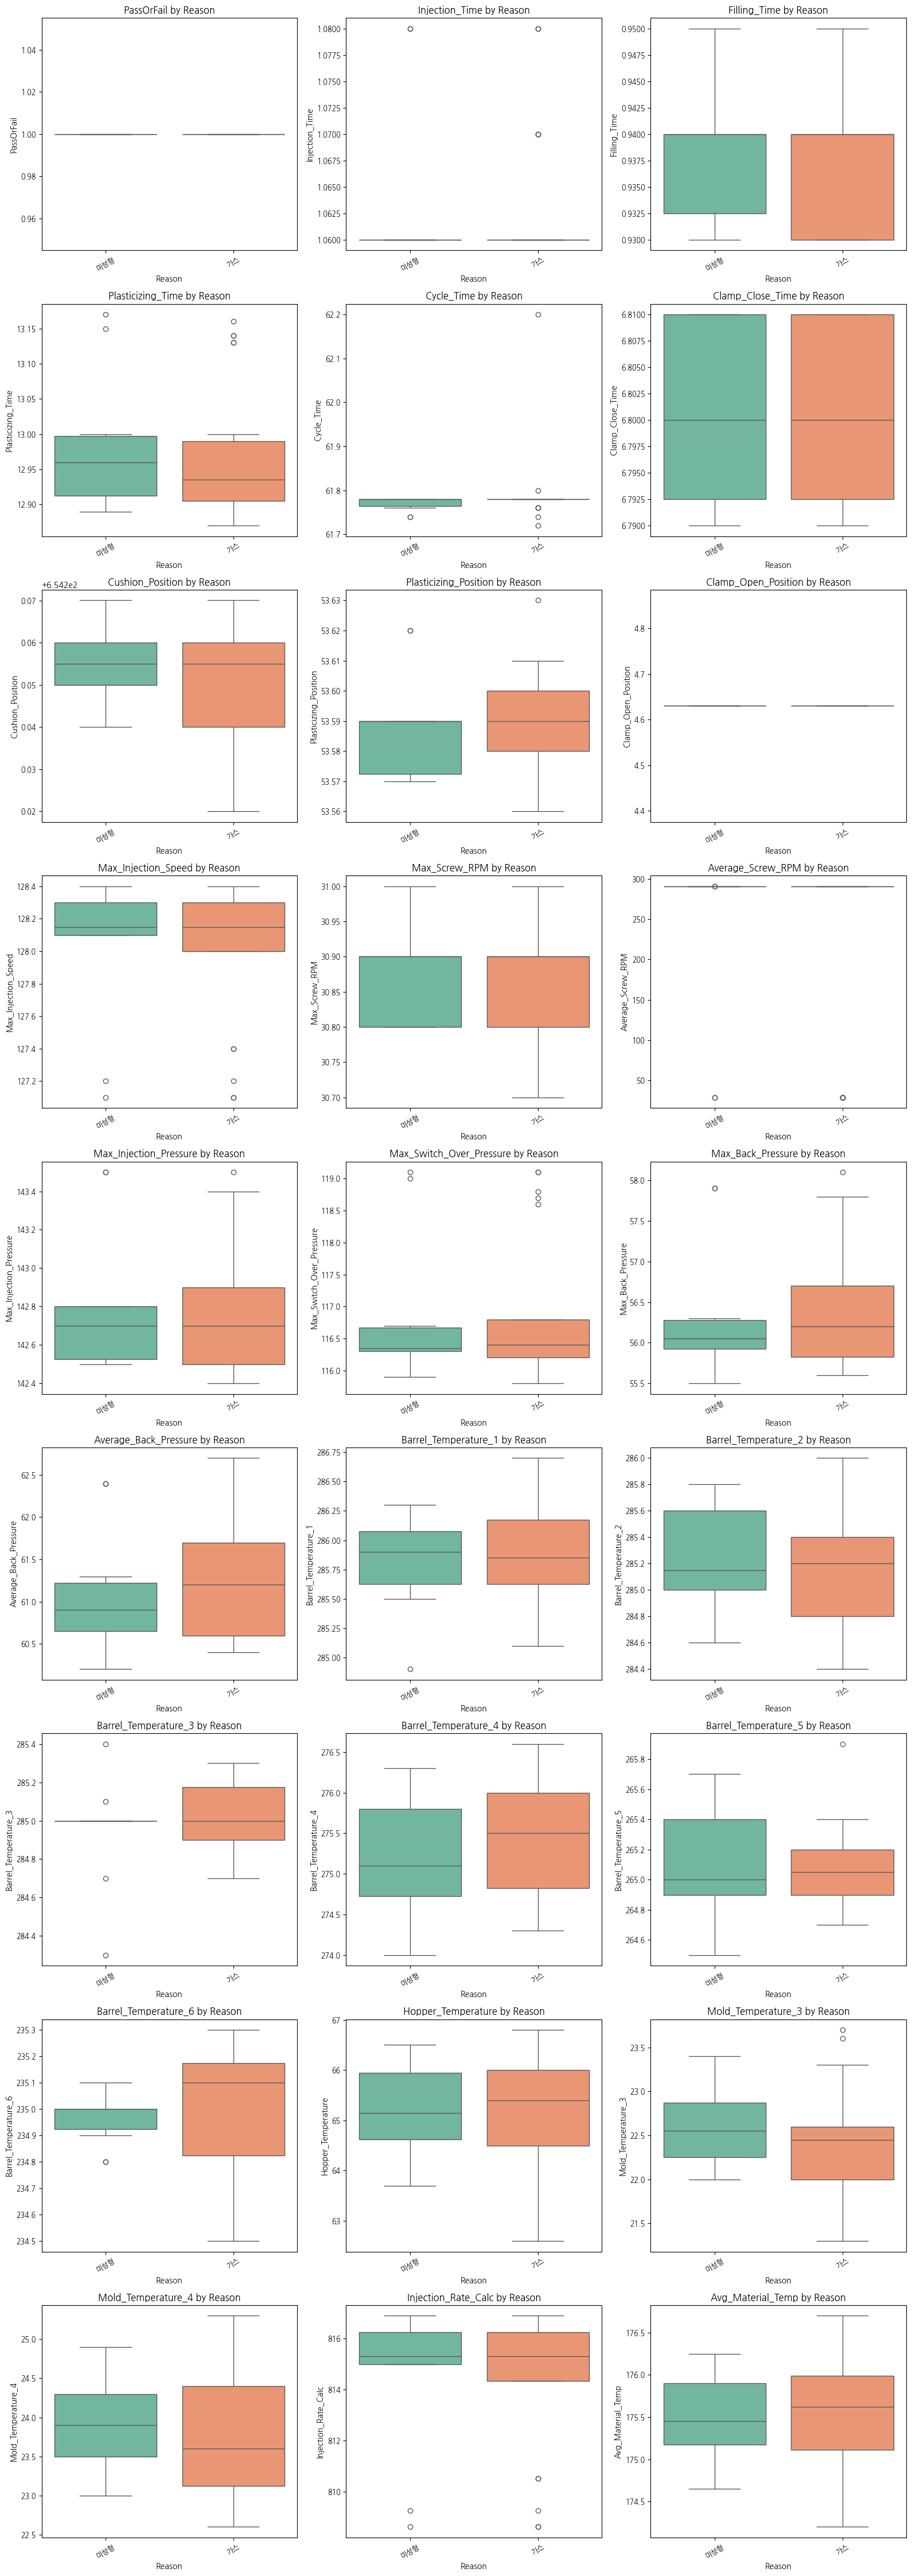

In [ ]:
# 수치형 컬럼만 선택 (PassOrFail 제외 가능)
numeric_columns = rg3.select_dtypes(include=['number']).columns

# 상위 5개 불량 원인만 시각화
top_reasons = rg3["Reason"].value_counts().head(5).index.tolist()
rg3_reason = rg3[rg3["Reason"].isin(top_reasons)]

# 그래프 구성
cols_per_row = 3
rows = int(np.ceil(len(numeric_columns) / cols_per_row))

plt.figure(figsize=(16, 5 * rows))
for i, col in enumerate(numeric_columns):
    plt.subplot(rows, cols_per_row, i + 1)
    sns.boxplot(data=rg3_reason, x='Reason', y=col, hue='Reason', palette='Set2', legend=False)
    plt.title(f'{col} by Reason', fontsize=12)
    plt.xlabel('Reason', fontsize=10)
    plt.ylabel(col, fontsize=10)
    plt.xticks(rotation=30, fontsize=9)
    plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

### 양품과 불량품 간의 분포 차이(rg3만)

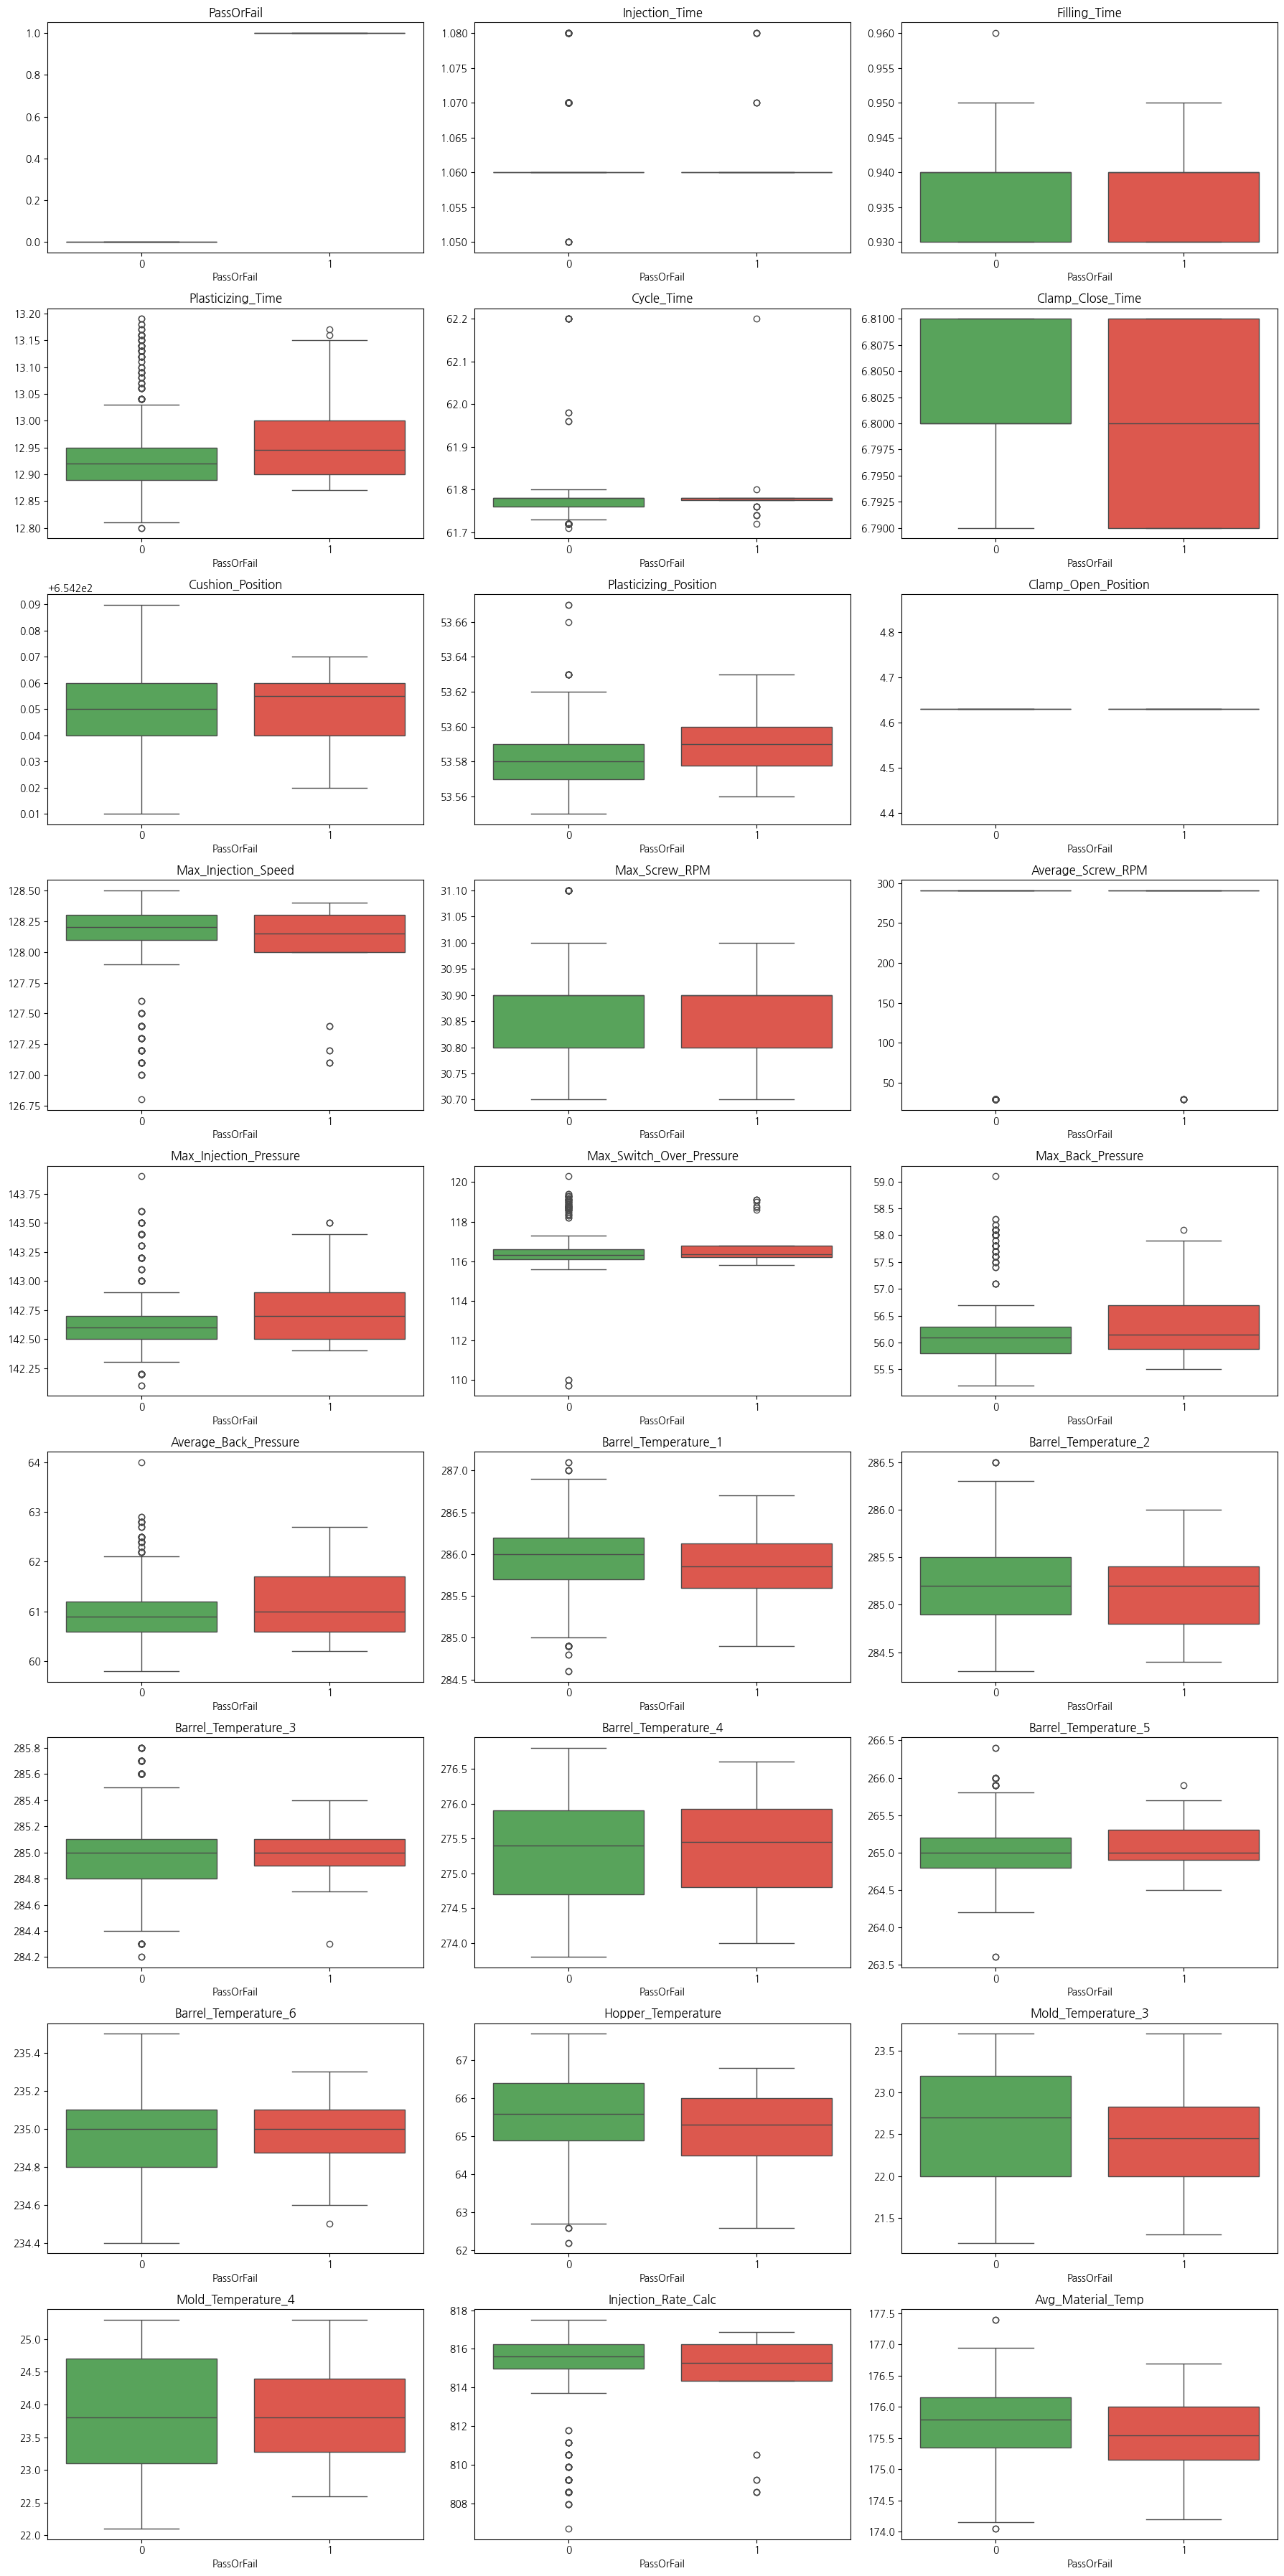

In [ ]:
# 수치형 컬럼만 선택
numeric_cols = rg3.select_dtypes(include=['float64', 'int64']).columns

# 한 줄에 3개씩 배치
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# 그래프 크기 설정
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*4))

# 색상 설정
palette = {'0': '#4CAF50', '1': '#F44336'}

# 각 컬럼별 박스 플롯 그리기
for idx, col in enumerate(numeric_cols):
    row, col_idx = divmod(idx, n_cols)
    sns.boxplot(x=rg3['PassOrFail'].astype(str), y=col, hue=rg3['PassOrFail'].astype(str),
                data=rg3, ax=axes[row, col_idx], palette=palette, legend=False)
    axes[row, col_idx].set_title(f'{col}', fontsize=12)
    axes[row, col_idx].set_xlabel('PassOrFail')
    axes[row, col_idx].set_ylabel('')

# 남는 빈 그래프 제거
for idx in range(len(numeric_cols), n_rows*n_cols):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()

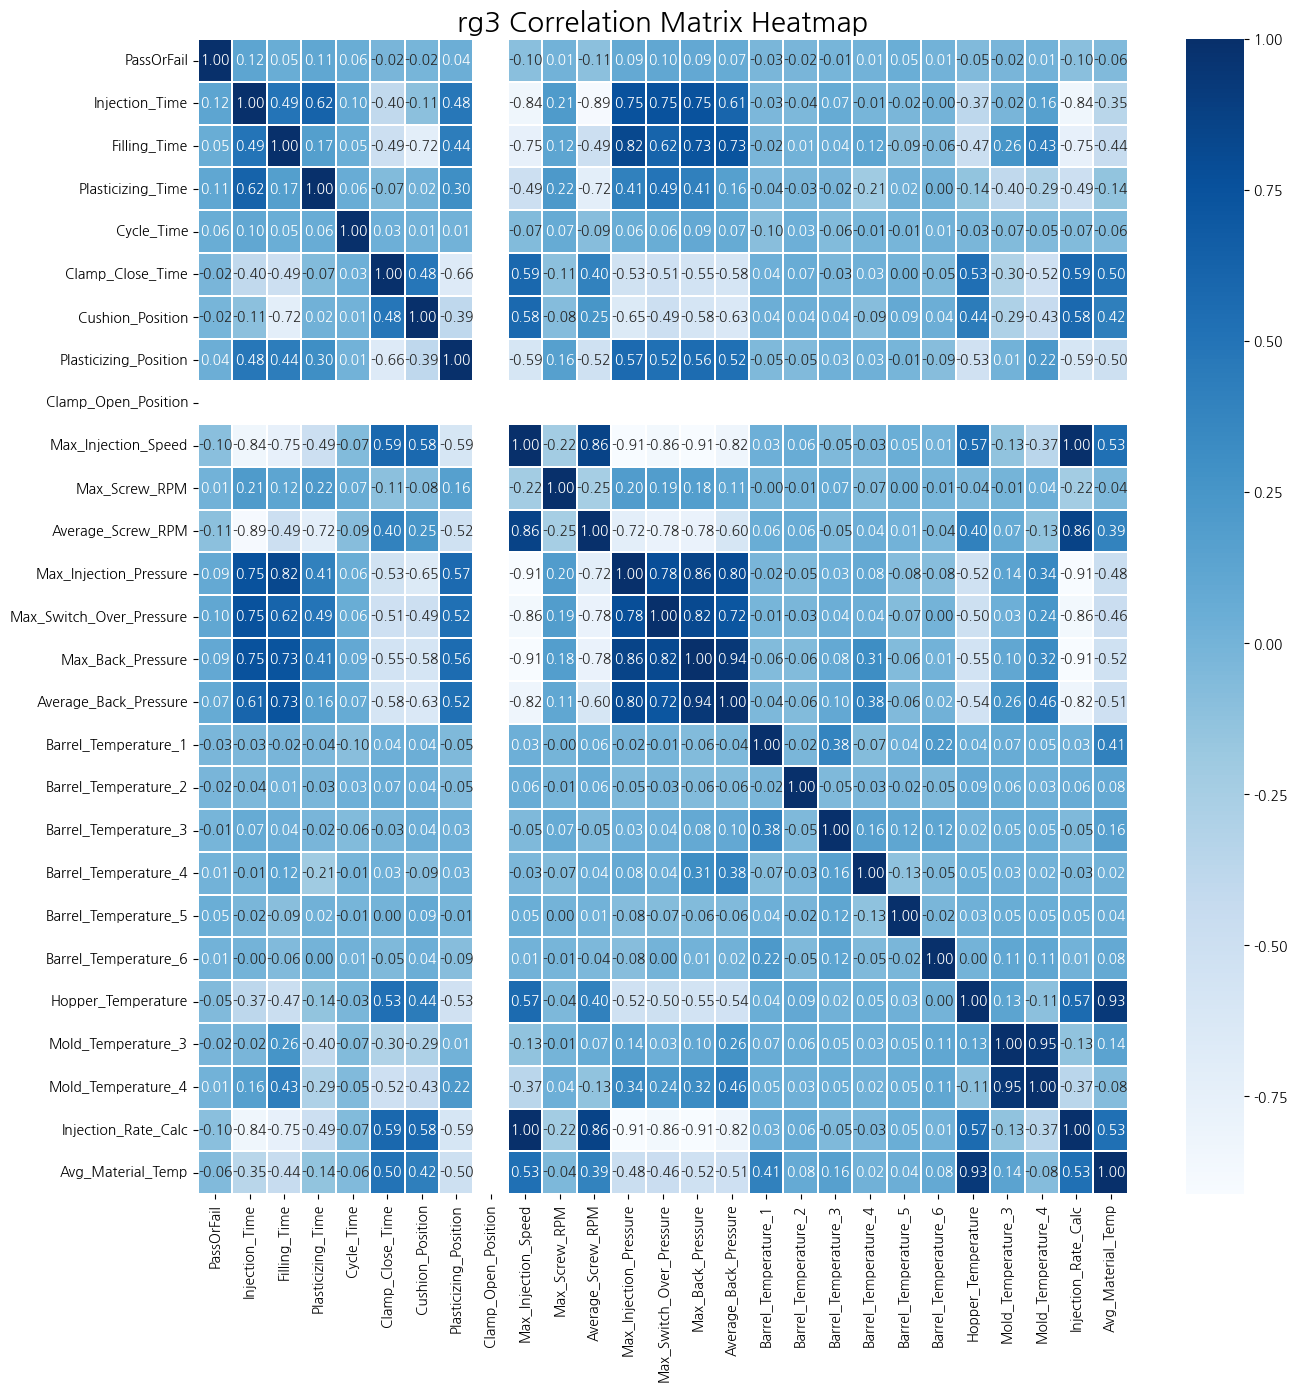

In [ ]:
# 수치형 컬럼만 선택
numeric_df = rg3.select_dtypes(include='number')

# 상관계수 계산
correlation_matrix = numeric_df.corr()

# 상관계수 히트맵 그리기
plt.subplots(figsize=(15, 15))  # 크기 조정
sns.heatmap(data=correlation_matrix, linewidths=0.1, annot=True, fmt='.2f', cmap='Blues')
plt.title('rg3 Correlation Matrix Heatmap', fontsize=20)
plt.show()

In [ ]:
# 제거할 컬럼 목록
columns_to_drop = [
    'Max_Screw_RPM',
    'Max_Back_Pressure',
    'Max_Injection_Pressure',
    'Clamp_Close_Time',
    'Max_Injection_Speed',
    'Barrel_Temperature_2',
    'Barrel_Temperature_3',
    'Barrel_Temperature_4',
    'Barrel_Temperature_5',
    'Barrel_Temperature_6',
    'Mold_Temperature_3'
]

rg3_reduced = rg3.drop(columns=columns_to_drop, errors='ignore')

# 새로운 파일로 저장
rg3_reduced.to_csv("rg3_reduced.csv", index=False)

## 머신러닝 진행(XGB)

In [ ]:
# 기존

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Injection_Time', 'Filling_Time',
       'Plasticizing_Time', 'Cycle_Time', 'Cushion_Position',
       'Plasticizing_Position', 'Clamp_Open_Position', 'Average_Screw_RPM',
       'Max_Switch_Over_Pressure', 'Average_Back_Pressure',
       'Barrel_Temperature_1', 'Hopper_Temperature', 'Mold_Temperature_4',
       'Injection_Rate_Calc']

X = rg3_reduced[features]
y = rg3_reduced[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# XGBoostㄴ 모델 훈련
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, max_depth=5)
xgb_model.fit(X_train, y_train)

# 예측
y_pred_xgb = xgb_model.predict(X_test)

# 정확도 및 F1 점수 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted'))

# 분류 보고서 출력
print("🔹 XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

🔹 XGBoost Accuracy: 0.9633757961783439
🔹 XGBoost F1 Score: 0.9563438560602538
🔹 XGBoost Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       612
           1       0.00      0.00      0.00        16

    accuracy                           0.96       628
   macro avg       0.49      0.49      0.49       628
weighted avg       0.95      0.96      0.96       628



## 머신러닝 진행(RF)

In [ ]:
# 기존

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Injection_Time', 'Filling_Time',
       'Plasticizing_Time', 'Cycle_Time', 'Cushion_Position',
       'Plasticizing_Position', 'Clamp_Open_Position', 'Average_Screw_RPM',
       'Max_Switch_Over_Pressure', 'Average_Back_Pressure',
       'Barrel_Temperature_1', 'Hopper_Temperature', 'Mold_Temperature_4',
       'Injection_Rate_Calc']

X = rg3[features]
y = rg3[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# Random Forest 모델 훈련
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# 예측
y_pred_rf = rf_model.predict(X_test)

print("🔹 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("🔹 Random Forest F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))
print("🔹 Random Forest Report:\n", classification_report(y_test, y_pred_rf))

🔹 Random Forest Accuracy: 0.9713375796178344
🔹 Random Forest F1 Score: 0.9603531481843531
🔹 Random Forest Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       612
           1       0.00      0.00      0.00        16

    accuracy                           0.97       628
   macro avg       0.49      0.50      0.49       628
weighted avg       0.95      0.97      0.96       628



## 머신러닝 진행(SVM)

In [ ]:
# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Injection_Time', 'Plasticizing_Time', 'Cycle_Time',
            'Average_Screw_RPM', 'Max_Switch_Over_Pressure',
            'Average_Back_Pressure', 'Mold_Temperature_4', 'Injection_Rate_Calc',
            'Avg_Material_Temp']

X = rg3[features]
y = rg3[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# 데이터 정규화 및 SVM 모델 생성
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# 모델 학습
svm_model.fit(X_train, y_train)

# 예측 수행
y_pred = svm_model.predict(X_test)

# SVM 모델 훈련 및 평가
# SVM은 데이터 스케일링에 민감하므로 StandardScaler를 사용하여 스케일링합니다.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("🔹 SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("🔹 SVM F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))
print("🔹 SVM Report:\n", classification_report(y_test, y_pred_svm))

🔹 SVM Accuracy: 0.9729299363057324
🔹 SVM F1 Score: 0.9611511235175275
🔹 SVM Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       612
           1       0.00      0.00      0.00        16

    accuracy                           0.97       628
   macro avg       0.49      0.50      0.49       628
weighted avg       0.95      0.97      0.96       628



## 너무 적은 불량품 수로 결과를 예측하는 게 어려워보임.

# -> CTGAN으로 불량품 수를 증강하여 분석 진행.

## CTGAN

### 불량 데이터 증강

In [ ]:
synthetic_data = pd.read_csv('/content/Filtered__Only_Fail__N__Samples.csv')

### 증강된 데이터 검증

In [ ]:
# 1. 데이터 타입 변환

# 'Y' -> 0, 'N' -> 1로 변경
rg3['PassOrFail'] = rg3['PassOrFail'].replace({'Y': 0, 'N': 1})
synthetic_data['PassOrFail'] = synthetic_data['PassOrFail'].replace({'Y': 0, 'N': 1})

# 데이터 타입 통일 (정수형으로 변환)
rg3['PassOrFail'] = rg3['PassOrFail'].astype(int)
synthetic_data['PassOrFail'] = synthetic_data['PassOrFail'].astype(int)

# 확인
print(rg3['PassOrFail'].value_counts())
print(synthetic_data['PassOrFail'].value_counts())

PassOrFail
0    1224
1      32
Name: count, dtype: int64
PassOrFail
1    332
Name: count, dtype: int64


<ipython-input-99-6d1b1fa5a061>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  synthetic_data['PassOrFail'] = synthetic_data['PassOrFail'].replace({'Y': 0, 'N': 1})


In [ ]:
rg3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PassOrFail                1256 non-null   int64  
 1   Reason                    32 non-null     object 
 2   Injection_Time            1256 non-null   float64
 3   Filling_Time              1256 non-null   float64
 4   Plasticizing_Time         1256 non-null   float64
 5   Cycle_Time                1256 non-null   float64
 6   Clamp_Close_Time          1256 non-null   float64
 7   Cushion_Position          1256 non-null   float64
 8   Plasticizing_Position     1256 non-null   float64
 9   Clamp_Open_Position       1256 non-null   float64
 10  Max_Injection_Speed       1256 non-null   float64
 11  Max_Screw_RPM             1256 non-null   float64
 12  Average_Screw_RPM         1256 non-null   float64
 13  Max_Injection_Pressure    1256 non-null   float64
 14  Max_Swit

In [ ]:
rg3

,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,group,Injection_Rate_Calc,Avg_Material_Temp
0,0,NaN,1.06,0.93,13.01,61.779999,6.81,654.289978,53.560001,4.63,...,285.000000,275.399994,265.100006,234.899994,65.800003,21.600000,22.500000,rg3,817.517000,175.900002
1,0,NaN,1.06,0.93,12.99,61.779999,6.81,654.280029,53.580002,4.63,...,285.000000,275.600006,265.600006,234.800003,65.800003,21.500000,22.500000,rg3,817.517000,176.000008
2,0,NaN,1.06,0.93,12.95,61.759998,6.81,654.270020,53.560001,4.63,...,285.000000,276.000000,265.100006,234.699997,65.900002,21.500000,22.500000,rg3,816.880761,176.200001
3,0,NaN,1.06,0.93,13.02,61.779999,6.81,654.270020,53.560001,4.63,...,284.500000,276.000000,264.799988,234.800003,65.900002,21.600000,22.500000,rg3,816.880761,175.599995
4,0,NaN,1.06,0.93,12.97,61.779999,6.81,654.280029,53.560001,4.63,...,285.600006,275.399994,265.000000,235.199997,65.800003,21.600000,22.500000,rg3,816.880761,176.049995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1251,0,NaN,1.07,0.94,13.06,61.779999,6.79,654.250000,53.610001,4.63,...,285.399994,276.100006,265.399994,235.199997,64.400002,22.500000,24.200001,rg3,811.155000,175.000004
1252,0,NaN,1.07,0.94,13.07,61.759998,6.79,654.260010,53.610001,4.63,...,285.000000,275.799988,264.899994,235.100006,64.599998,22.400000,24.200001,rg3,811.791190,175.100002
1253,0,NaN,1.07,0.94,13.09,61.740002,6.79,654.250000,53.619999,4.63,...,285.100006,275.500000,265.000000,235.000000,63.000000,22.600000,24.400000,rg3,811.155000,174.600006
1254,0,NaN,1.07,0.94,13.12,61.779999,6.79,654.250000,53.610001,4.63,...,285.700012,274.899994,265.000000,234.899994,64.500000,22.500000,24.299999,rg3,811.155000,175.199997


In [ ]:
synthetic_data

,Unnamed: 0,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,605,1,미성형,1.08,0.95,13.15,61.779999,6.79,654.250000,53.619999,...,62.400002,285.799988,284.600006,285.000000,275.799988,264.899994,234.800003,64.699997,22.400000,24.299999
1,606,1,미성형,1.08,0.95,13.17,61.779999,6.79,654.260010,53.619999,...,62.400002,285.600006,285.600006,285.000000,276.299988,264.500000,234.800003,63.700001,22.400000,24.299999
2,607,1,가스,1.07,0.95,13.14,61.779999,6.79,654.219971,53.630001,...,62.200001,285.600006,284.600006,285.299988,276.000000,265.000000,235.199997,63.700001,22.500000,24.400000
3,614,1,가스,1.07,0.94,13.13,61.779999,6.79,654.239990,53.599998,...,62.099998,286.100006,285.200012,285.000000,275.700012,265.299988,235.300003,64.500000,22.500000,24.400000
4,615,1,가스,1.07,0.94,13.13,61.759998,6.79,654.239990,53.599998,...,61.900002,285.799988,284.799988,284.899994,275.299988,265.000000,235.199997,62.599998,22.500000,24.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,1551,1,NaN,1.06,0.93,12.96,61.779999,6.80,654.270020,53.590000,...,61.000000,286.100006,285.299988,285.000000,275.899994,265.000000,235.000000,66.000000,22.000000,23.000000
328,1552,1,NaN,1.06,0.93,12.90,61.779999,6.80,654.260010,53.590000,...,61.000000,286.600006,284.600006,285.000000,276.500000,264.899994,235.000000,66.800003,22.000000,23.100000
329,1553,1,NaN,1.06,0.93,12.94,61.779999,6.80,654.270020,53.580002,...,60.599998,286.299988,285.399994,284.899994,276.299988,265.200012,234.800003,65.900002,22.000000,23.100000
330,1554,1,NaN,1.06,0.94,12.93,61.779999,6.81,654.260010,53.560001,...,60.500000,285.700012,285.200012,285.000000,275.600006,265.100006,235.100006,66.199997,22.299999,23.400000


In [ ]:
synthetic_data['PassOrFail'].value_counts()

,count
PassOrFail,
1,332


🔹 XGBoost Accuracy: 0.9601910828025477
🔹 XGBoost F1 Score: 0.9547310197809248
🔹 XGBoost Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       612
           1       0.00      0.00      0.00        16

    accuracy                           0.96       628
   macro avg       0.49      0.49      0.49       628
weighted avg       0.95      0.96      0.95       628



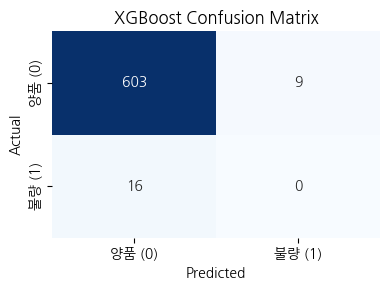

In [ ]:
# 2. 기존 rg3 데이터로 모델 학습 및 성능 확인

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = rg3.columns.drop([target, 'Reason', 'group'])  # 'Reason' 컬럼 제외

X = rg3[features]
y = rg3[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# ✅ XGBoost 모델 훈련
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# 예측
y_pred_xgb = xgb_model.predict(X_test)

# 평가 지표 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted'))
print("🔹 XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

# ✅ Confusion Matrix 시각화 (고정된 label 순서)
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["양품 (0)", "불량 (1)"],
                yticklabels=["양품 (0)", "불량 (1)"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test, y_pred_xgb, title="XGBoost Confusion Matrix")

🔹 XGBoost Accuracy: 0.7260416666666667
🔹 XGBoost F1 Score: 0.674474882984488
🔹 XGBoost Report:
               precision    recall  f1-score   support

           0       0.70      0.99      0.82       612
           1       0.91      0.27      0.42       348

    accuracy                           0.73       960
   macro avg       0.81      0.63      0.62       960
weighted avg       0.78      0.73      0.67       960



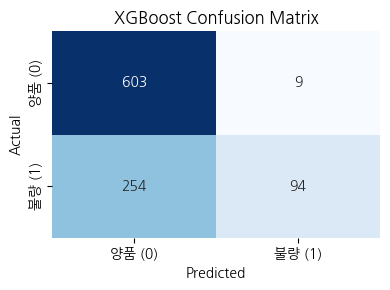

In [ ]:
# 3. test set에 기존 rg3 데이터 & 증강데이터(synthetic_data)로 모델 학습 및 성능 확인

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"

# ✅ synthetic_data의 컬럼을 기준으로 features 정의
features = rg3.columns.drop([target, 'Reason', 'group', 'Injection_Rate_Calc', 'Avg_Material_Temp'])  # 'Reason' , 파생변수 컬럼 제외

# ✅ RG3 데이터 분할
X = rg3[features]
y = rg3[target]

X_train_rg3, X_test_rg3, y_train_rg3, y_test_rg3 = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

# ✅ 증강 데이터 준비 (test set에 추가)
X_synthetic = synthetic_data[features]
y_synthetic = synthetic_data[target]

X_test_combined = pd.concat([X_test_rg3, X_synthetic], ignore_index=True)
y_test_combined = pd.concat([y_test_rg3, y_synthetic], ignore_index=True)

# ✅ XGBoost 모델 학습 & 예측
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_rg3, y_train_rg3)
y_pred_xgb = xgb_model.predict(X_test_combined)

# ✅ 평가 결과 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test_combined, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test_combined, y_pred_xgb, average='weighted'))
print("🔹 XGBoost Report:\n", classification_report(y_test_combined, y_pred_xgb))

# ✅ Confusion Matrix 시각화 함수
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["양품 (0)", "불량 (1)"],
                yticklabels=["양품 (0)", "불량 (1)"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test_combined, y_pred_xgb, title="XGBoost Confusion Matrix")

🔹 XGBoost Accuracy: 0.7260416666666667
🔹 XGBoost F1 Score: 0.674474882984488
🔹 XGBoost Report:
               precision    recall  f1-score   support

           0       0.70      0.99      0.82       612
           1       0.91      0.27      0.42       348

    accuracy                           0.73       960
   macro avg       0.81      0.63      0.62       960
weighted avg       0.78      0.73      0.67       960



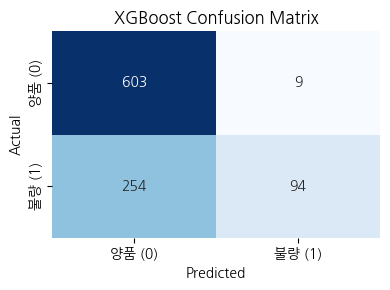

In [ ]:
# 3. test set에 기존 rg3 데이터 & 증강데이터(synthetic_data)로 모델 학습 및 성능 확인

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"

# ✅ synthetic_data의 컬럼을 기준으로 features 정의
features = rg3.columns.drop([target, 'Reason', 'group', 'Injection_Rate_Calc', 'Avg_Material_Temp'])

# ✅ RG3 데이터 분할
X = rg3[features]
y = rg3[target]

X_train_rg3, X_test_rg3, y_train_rg3, y_test_rg3 = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

# ✅ 증강 데이터 준비 (test set에 추가)
X_synthetic = synthetic_data[features]
y_synthetic = synthetic_data[target]

X_test_combined = pd.concat([X_test_rg3, X_synthetic], ignore_index=True)
y_test_combined = pd.concat([y_test_rg3, y_synthetic], ignore_index=True)

# ✅ XGBoost 모델 학습 & 예측
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_rg3, y_train_rg3)
y_pred_xgb = xgb_model.predict(X_test_combined)

# ✅ 평가 결과 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test_combined, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test_combined, y_pred_xgb, average='weighted'))
print("🔹 XGBoost Report:\n", classification_report(y_test_combined, y_pred_xgb))

# ✅ Confusion Matrix 시각화 함수
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["양품 (0)", "불량 (1)"],
                yticklabels=["양품 (0)", "불량 (1)"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test_combined, y_pred_xgb, title="XGBoost Confusion Matrix")

In [ ]:
# 증강데이터 불러오기(양품+불량품)
rg3_aug = pd.read_csv('/content/Combined_Dataset_with_300_Synthetic_Fails.csv')

# 데이터 타입 변환
# 'Y' -> 0, 'N' -> 1로 변경
rg3_aug['PassOrFail'] = rg3_aug['PassOrFail'].replace({'Y': 0, 'N': 1})

# 데이터 타입 통일 (정수형으로 변환)
rg3_aug['PassOrFail'] = rg3_aug['PassOrFail'].astype(int)

# 확인
print(rg3_aug['PassOrFail'].value_counts())

PassOrFail
0    1224
1     332
Name: count, dtype: int64


<ipython-input-94-0e222a89fc6e>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rg3_aug['PassOrFail'] = rg3_aug['PassOrFail'].replace({'Y': 0, 'N': 1})


🔹 XGBoost Accuracy: 1.0
🔹 XGBoost F1 Score: 1.0
🔹 XGBoost Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        32

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



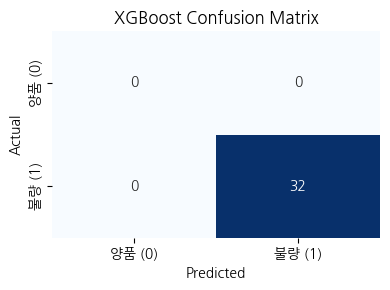

In [ ]:
# 4. train : 증강데이터 / test : 증강 전(기존의 불량 데이터만)

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = rg3_aug.columns.drop([target, 'Reason'])  # 'Reason' 컬럼 제외

# ✅ stratify로 1, 0 비율 유지한 채 절반 샘플링
rg3_aug_half, _ = train_test_split(
    rg3_aug,
    test_size=0.5,
    random_state=42,
    stratify=rg3_aug['PassOrFail']
)

X_train = rg3_aug_half[features]
y_train = rg3_aug_half[target]

# ✅ Test set: RG3 데이터 중 불량 샘플만
rg3_fault = rg3[rg3[target] == 1]
X_test = rg3_fault[features]
y_test = rg3_fault[target]

# ✅ XGBoost 모델 학습 & 예측
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# ✅ 평가 지표 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted'))
print("🔹 XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

# ✅ 혼동 행렬 시각화 함수 (재사용)
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["양품 (0)", "불량 (1)"],
                yticklabels=["양품 (0)", "불량 (1)"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test, y_pred_xgb, title="XGBoost Confusion Matrix")

🔹 XGBoost Accuracy: 1.0
🔹 XGBoost F1 Score: 1.0
🔹 XGBoost Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00       332

    accuracy                           1.00       332
   macro avg       1.00      1.00      1.00       332
weighted avg       1.00      1.00      1.00       332



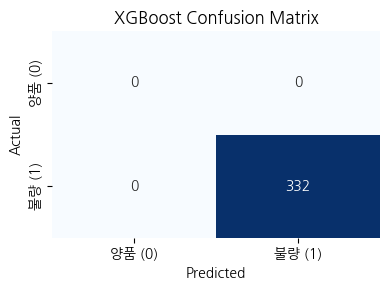

In [ ]:
# 5. train : 증강데이터 / test : 증강 후(증강한 불량 데이터만)

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = rg3_aug.columns.drop([target, 'Reason'])  # 'Reason' 컬럼 제외

# ✅ stratify로 1, 0 비율 유지한 채 절반 샘플링
rg3_aug_half, _ = train_test_split(
    rg3_aug,
    test_size=0.5,
    random_state=42,
    stratify=rg3_aug['PassOrFail']
)

X_train = rg3_aug_half[features]
y_train = rg3_aug_half[target]

# ✅ Test set: 증강데이터 중 불량 샘플만
X_test = synthetic_data[features]
y_test = synthetic_data[target]

# ✅ XGBoost 모델 학습 & 예측
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# ✅ 평가 지표 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted'))
print("🔹 XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

# ✅ 혼동 행렬 시각화 함수
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["양품 (0)", "불량 (1)"],
                yticklabels=["양품 (0)", "불량 (1)"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test, y_pred_xgb, title="XGBoost Confusion Matrix")

🔹 XGBoost Accuracy: 0.9745222929936306
🔹 XGBoost F1 Score: 0.9785998509582261
🔹 XGBoost Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99      1224
           1       0.50      1.00      0.67        32

    accuracy                           0.97      1256
   macro avg       0.75      0.99      0.83      1256
weighted avg       0.99      0.97      0.98      1256



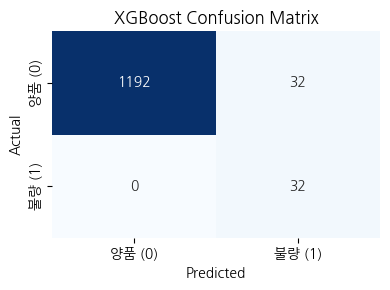

In [ ]:
# 6. train : 증강데이터 / test : 기존 데이터(양품+불량품)

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = rg3_aug.columns.drop([target, 'Reason'])  # 'Reason' 컬럼 제외

# ✅ stratify로 1, 0 비율 유지한 채 절반 샘플링
rg3_aug_half, _ = train_test_split(
    rg3_aug,
    test_size=0.5,
    random_state=42,
    stratify=rg3_aug['PassOrFail']
)

X_train = rg3_aug_half[features]
y_train = rg3_aug_half[target]

# ✅ Test set: 기존 데이터 전체
X_test = rg3[features]
y_test = rg3[target]

# ✅ XGBoost 모델 학습 & 예측
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# ✅ 평가 지표 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted'))
print("🔹 XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

# ✅ 혼동 행렬 시각화 함수
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["양품 (0)", "불량 (1)"],
                yticklabels=["양품 (0)", "불량 (1)"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test, y_pred_xgb, title="XGBoost Confusion Matrix")

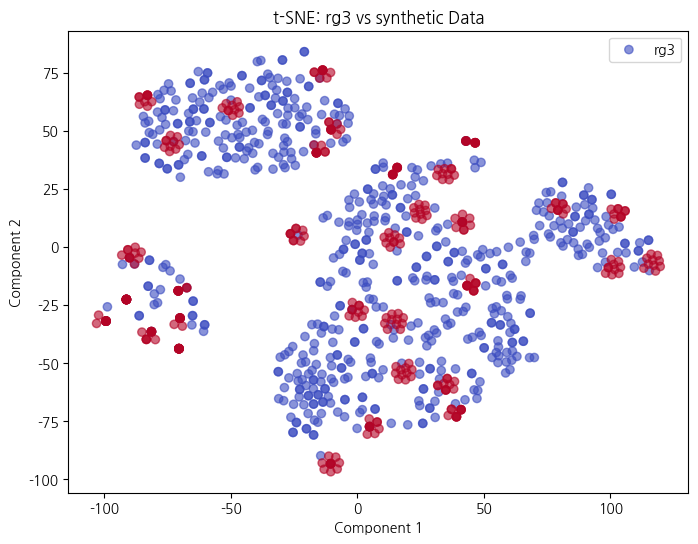

In [ ]:
# t-SNE or PCA 시각화로 기존 vs 증강 분포 비교

X_vis = pd.concat([X_test_rg3, X_synthetic])
y_vis = ['rg3'] * len(X_test_rg3) + ['synthetic'] * len(X_synthetic)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_vis)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=[0 if label == 'rg3' else 1 for label in y_vis], cmap='coolwarm', alpha=0.6)
plt.title("t-SNE: rg3 vs synthetic Data")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(['rg3', 'synthetic'])
plt.show()

### 증강한 데이터의 파생 변수 생성 및 히트맵 확인

In [ ]:
# 데이터 불러오기
rg3_aug = pd.read_csv('/content/Combined_Dataset_with_300_Synthetic_Fails.csv')

# 데이터 타입 변환
# 'Y' -> 0, 'N' -> 1로 변경
rg3_aug['PassOrFail'] = rg3_aug['PassOrFail'].replace({'Y': 0, 'N': 1})

# 데이터 타입 통일 (정수형으로 변환)
rg3_aug['PassOrFail'] = rg3_aug['PassOrFail'].astype(int)

# 확인
print(rg3_aug['PassOrFail'].value_counts())

PassOrFail
0    1224
1     332
Name: count, dtype: int64


<ipython-input-114-9e5a88737838>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rg3_aug['PassOrFail'] = rg3_aug['PassOrFail'].replace({'Y': 0, 'N': 1})


In [ ]:
# 파생 변수 생성

# 몰드 온도 평균
rg3_aug['Mean_Mold_Temp'] = (rg3_aug['Mold_Temperature_3'] + rg3_aug['Mold_Temperature_4']) / 2

#  시간 비율
rg3_aug['Filling_Ratio'] = rg3_aug['Filling_Time'] / rg3_aug['Injection_Time']

# 백압 vs. 인젝션 압력 차이
rg3_aug['Avg_Back_Pressure_Ratio'] = rg3_aug['Average_Back_Pressure'] / rg3_aug['Max_Back_Pressure']

rg3_aug['Avg_Material_Temp'] = (rg3_aug['Hopper_Temperature'] + rg3_aug['Barrel_Temperature_1']) / 2

# 스크류 단면적 (단위: cm²) - 제공된 값 사용
screw_cross_section_area_cm2 = 63.62

# 사출속도 (단위: mm/s) → cm/s로 변환
injection_speed_cm_per_s = rg3_aug["Max_Injection_Speed"] / 10

# 사출률 계산: 단면적(cm²) × 속도(cm/s) = cm³/s
rg3_aug["Injection_Rate_Calc"] = screw_cross_section_area_cm2 * injection_speed_cm_per_s

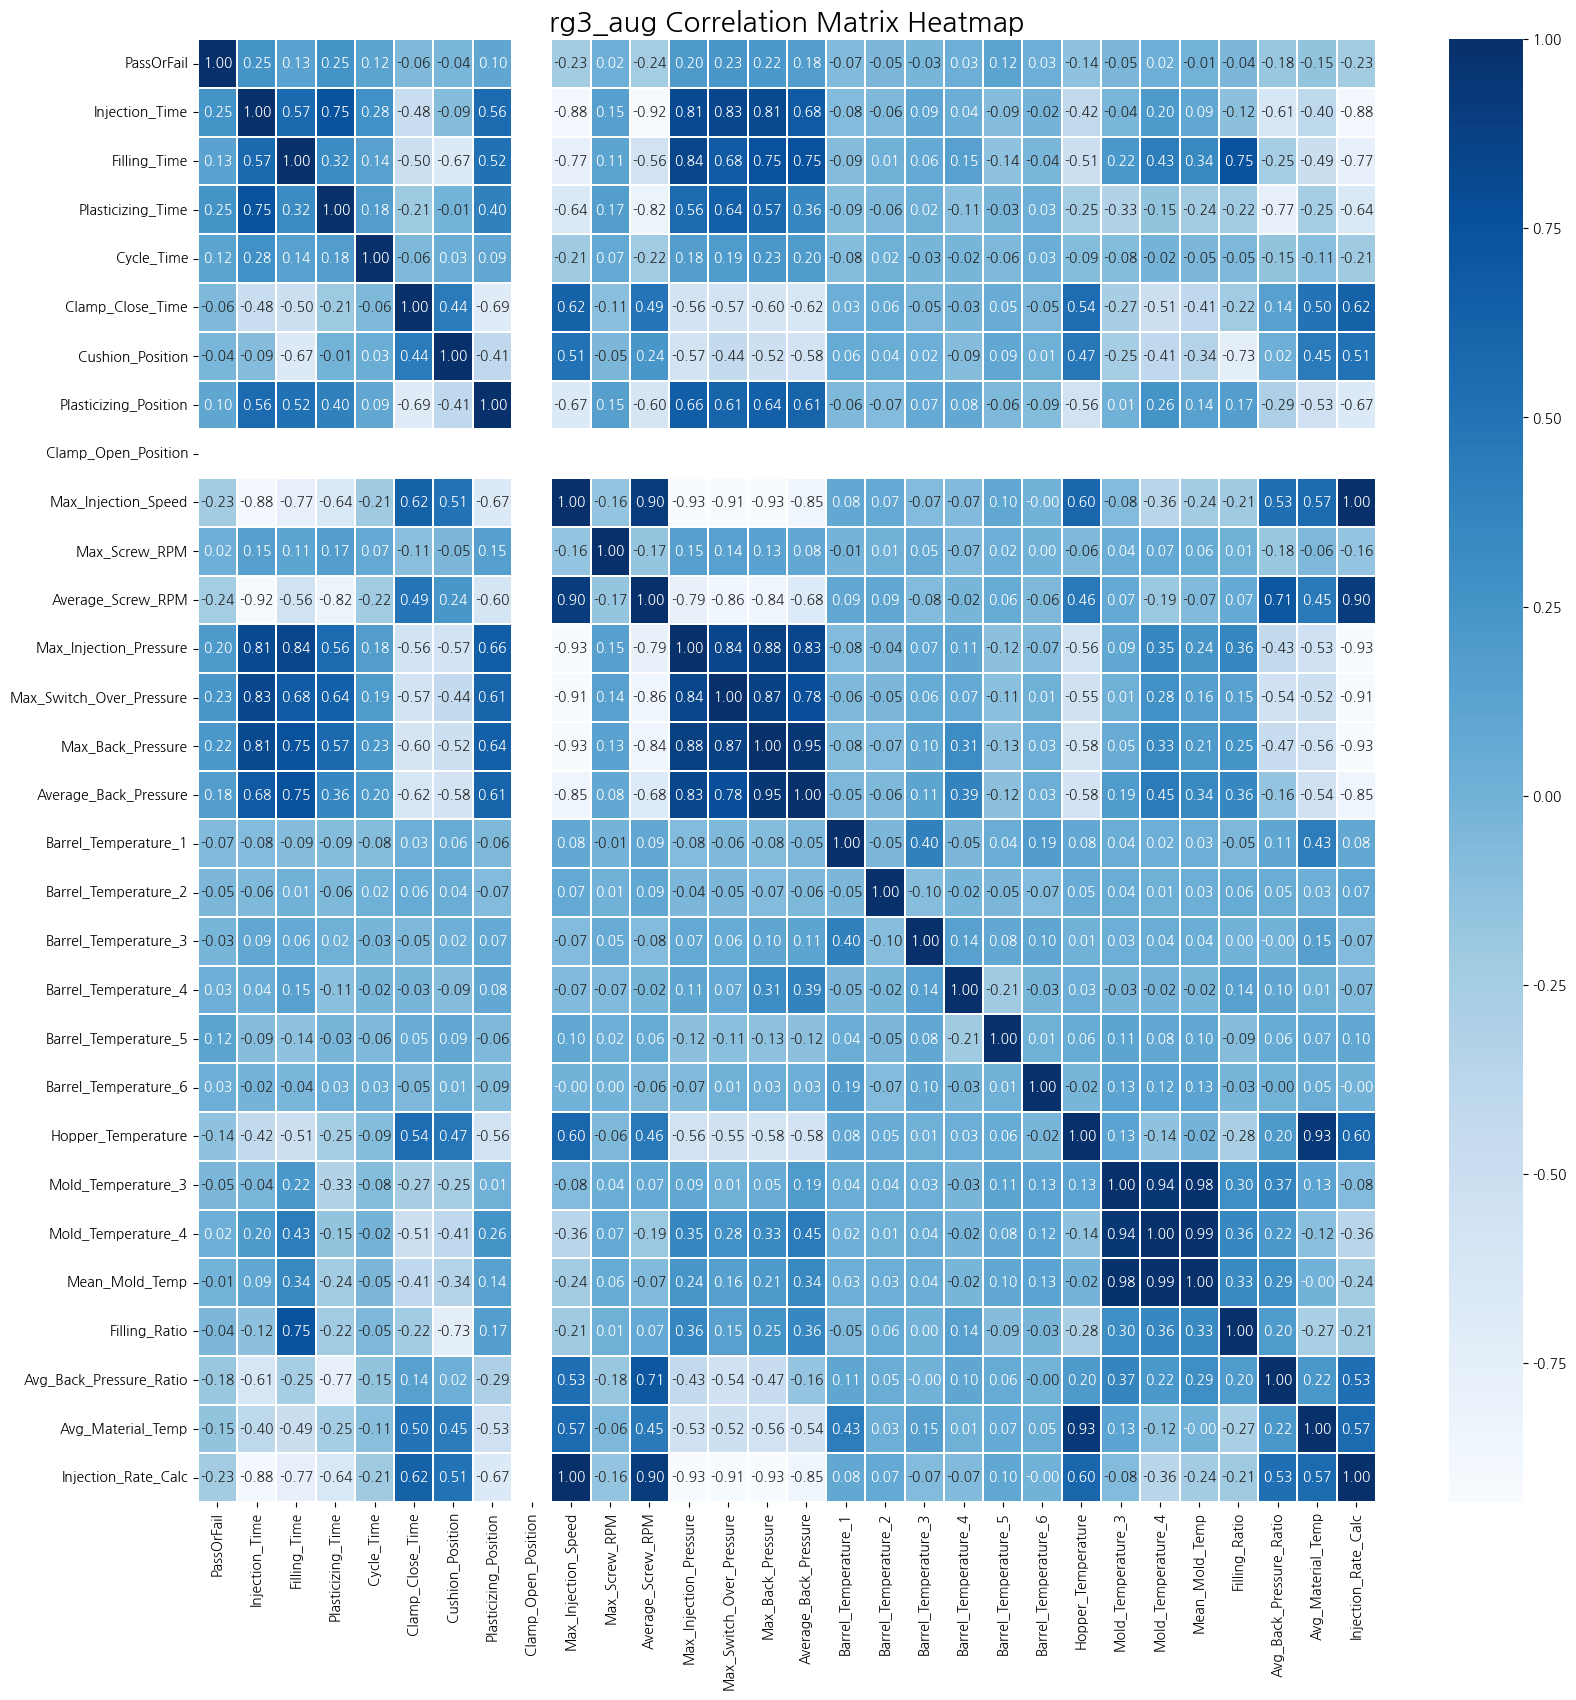

In [ ]:
# 수치형 컬럼만 선택
numeric_df = rg3_aug.select_dtypes(include='number')

# 상관계수 계산
correlation_matrix = numeric_df.corr()

# 상관계수 히트맵 그리기
plt.subplots(figsize=(19, 19))  # 크기 조정
sns.heatmap(data=correlation_matrix, linewidths=0.1, annot=True, fmt='.2f', cmap='Blues')
plt.title('rg3_aug Correlation Matrix Heatmap', fontsize=20)
plt.show()

### 증강한 데이터의 분포

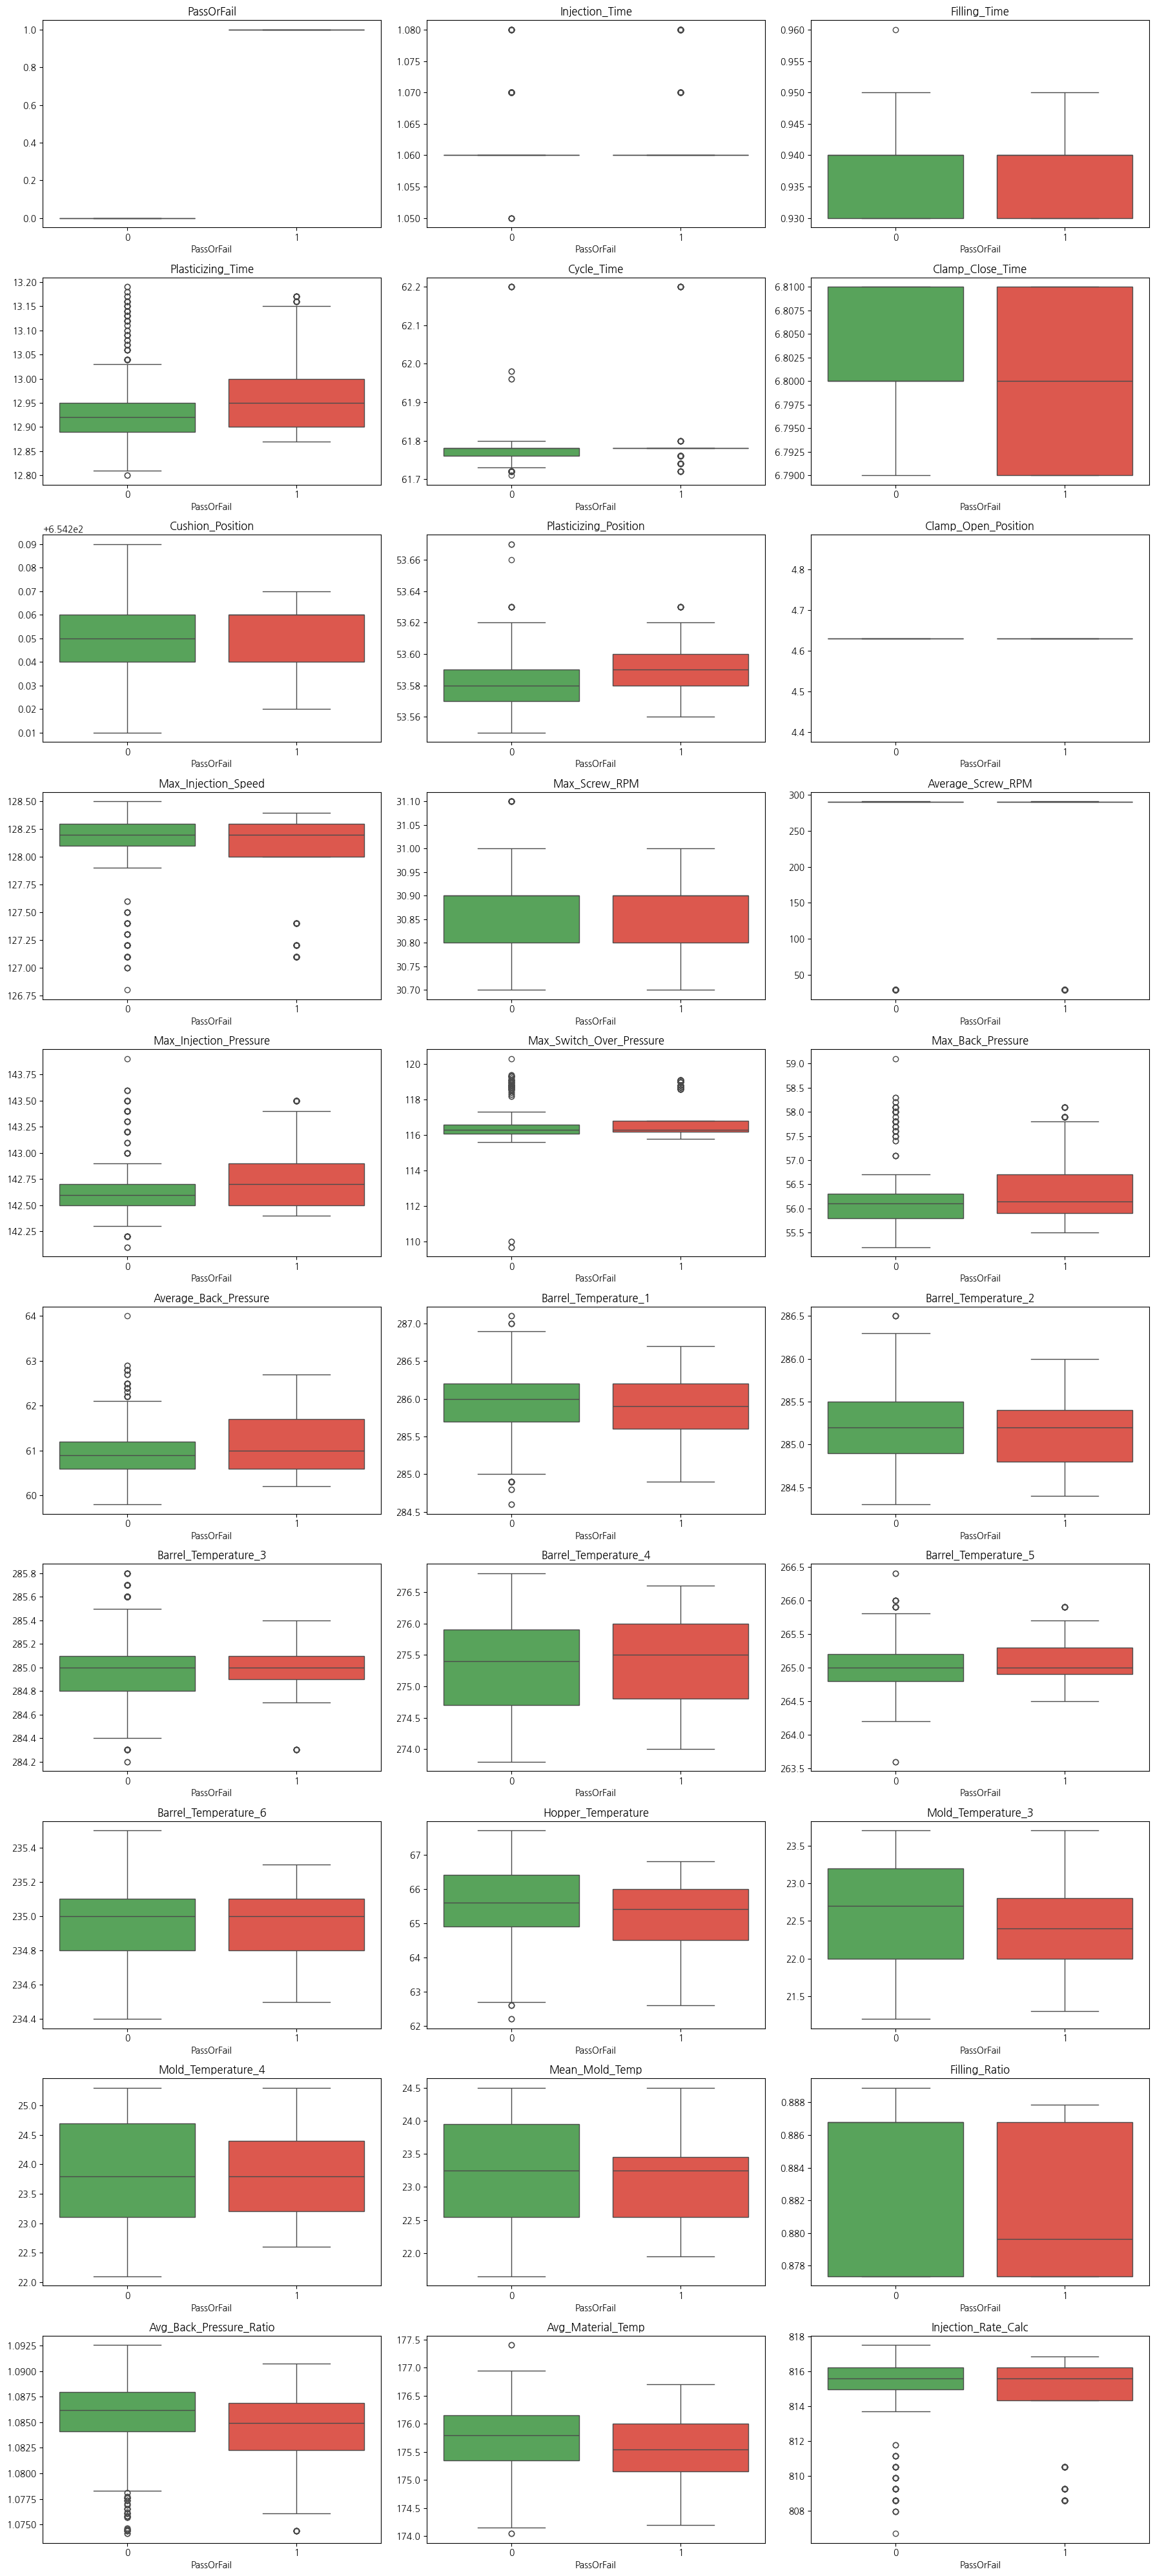

In [ ]:
# 수치형 컬럼만 선택
numeric_cols = rg3_aug.select_dtypes(include=['float64', 'int64']).columns

# 한 줄에 3개씩 배치
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# 그래프 크기 설정
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*4))

# 색상 설정
palette = {'0': '#4CAF50', '1': '#F44336'}

# 각 컬럼별 박스 플롯 그리기
for idx, col in enumerate(numeric_cols):
    row, col_idx = divmod(idx, n_cols)
    sns.boxplot(x=rg3_aug['PassOrFail'].astype(str), y=col, hue=rg3_aug['PassOrFail'].astype(str),
                data=rg3_aug, ax=axes[row, col_idx], palette=palette, legend=False)
    axes[row, col_idx].set_title(f'{col}', fontsize=12)
    axes[row, col_idx].set_xlabel('PassOrFail')
    axes[row, col_idx].set_ylabel('')

# 남는 빈 그래프 제거
for idx in range(len(numeric_cols), n_rows*n_cols):
    fig.delaxes(axes.flatten()[idx])

plt.tight_layout()
plt.show()

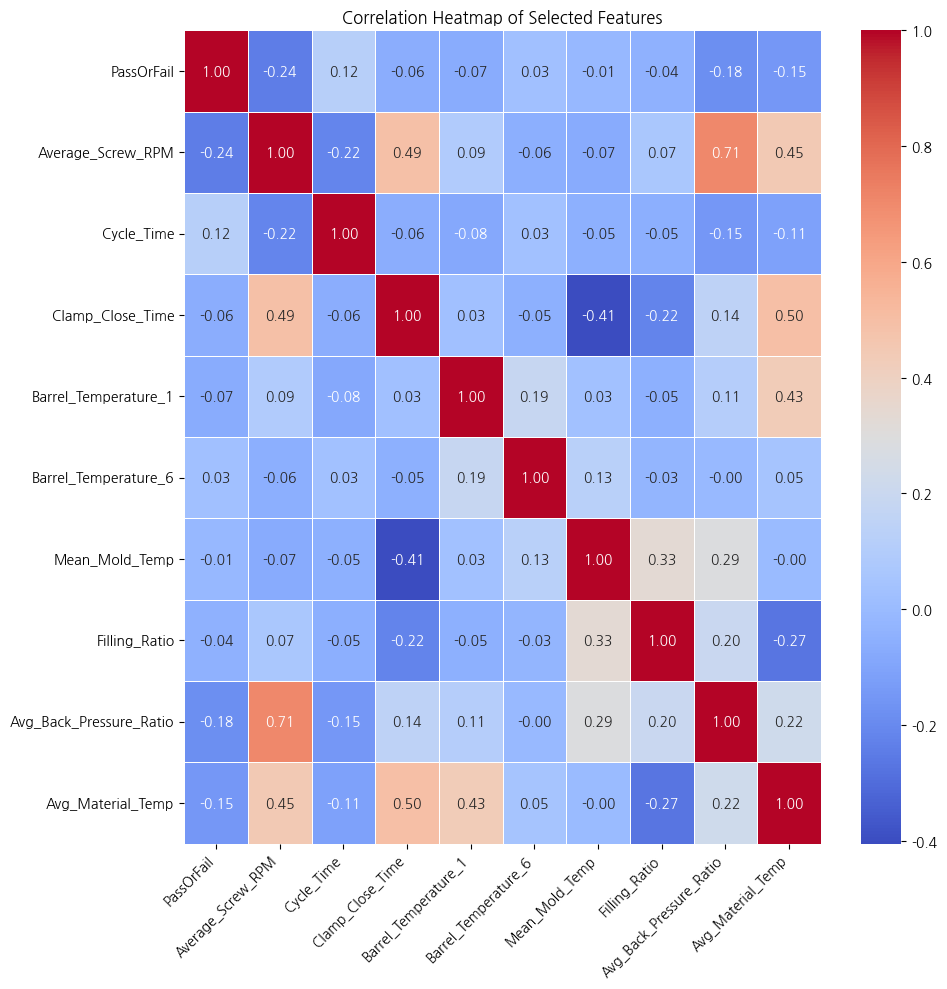

In [ ]:
# 사용할 컬럼 목록
selected_columns = [ 'PassOrFail','Average_Screw_RPM',
       'Cycle_Time', 'Clamp_Close_Time',
       'Barrel_Temperature_1',
        'Barrel_Temperature_6',
        'Mean_Mold_Temp',
       'Filling_Ratio',
       'Avg_Back_Pressure_Ratio',
        'Avg_Material_Temp',
        ]

# 선택된 컬럼만으로 데이터프레임 생성
rg3_aug_selected =rg3_aug[selected_columns]

# 상관관계 행렬 계산
correlation_matrix =rg3_aug_selected.corr()

# 히트맵 그리기
plt.figure(figsize=(10, 10))  # 필요에 따라 figsize 조정
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Selected Features')
plt.xticks(rotation=45, ha='right')  # x축 레이블 회전
plt.yticks(rotation=0)  # y축 레이블 회전
plt.tight_layout() # 레이아웃 조정
plt.show()

## 머신러닝 (XGB)

🔹 XGBoost Accuracy: 0.9730077120822622
🔹 XGBoost F1 Score: 0.9735750052979149
🔹 XGBoost Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98       612
           1       0.89      1.00      0.94       166

    accuracy                           0.97       778
   macro avg       0.94      0.98      0.96       778
weighted avg       0.98      0.97      0.97       778



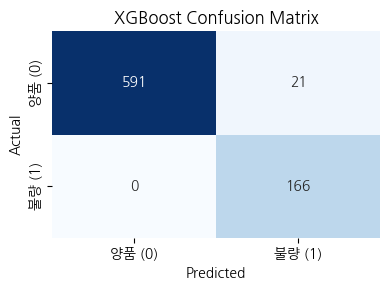

✅ Train Accuracy: 0.9833
✅ Test Accuracy: 0.9730
과적합이 의심되지 않습니다.


In [ ]:
# 기존

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Average_Screw_RPM',
       'Cycle_Time', 'Clamp_Close_Time',
       'Barrel_Temperature_1',
        'Barrel_Temperature_6',
        'Mean_Mold_Temp',
       'Filling_Ratio',
       'Avg_Back_Pressure_Ratio',
        'Avg_Material_Temp',
        ]
X = rg3_aug[features]
y = rg3_aug[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# XGBoost 모델 훈련
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, max_depth=5)
xgb_model.fit(X_train, y_train)

# 예측
y_pred_xgb = xgb_model.predict(X_test)

# 정확도 및 F1 점수 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted'))

# 분류 보고서 출력
print("🔹 XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

# 혼동 행렬 시각화
plot_conf_matrix(y_test, y_pred_xgb, title="XGBoost Confusion Matrix")

train_acc = xgb_model.score(X_train, y_train)  # 훈련 데이터 정확도
test_acc = xgb_model.score(X_test, y_test)  # 테스트 데이터 정확도

print(f"✅ Train Accuracy: {train_acc:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")

# 과적합 여부 확인
if train_acc - test_acc > 0.1:  # 임계값 조정 가능
    print("과적합이 의심됩니다.")
else:
    print("과적합이 의심되지 않습니다.")

## 머신러닝 (RF)

🔹 Random Forest Accuracy: 0.8290488431876607
🔹 Random Forest F1 Score: 0.7910917946930207
🔹 Random Forest Report:
               precision    recall  f1-score   support

           0       0.83      0.99      0.90       612
           1       0.82      0.25      0.39       166

    accuracy                           0.83       778
   macro avg       0.83      0.62      0.64       778
weighted avg       0.83      0.83      0.79       778



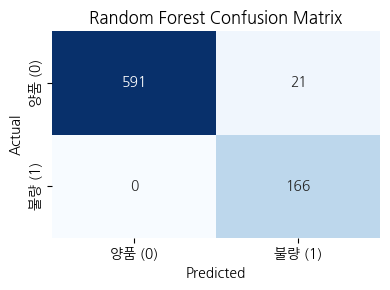

In [ ]:
# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Average_Screw_RPM',
       'Cycle_Time', 'Clamp_Close_Time',
       'Barrel_Temperature_1',
        'Barrel_Temperature_6',
        'Mean_Mold_Temp',
       'Filling_Ratio',
       'Avg_Back_Pressure_Ratio',
        'Avg_Material_Temp',
        ]

X = rg3_aug[features]
y = rg3_aug[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# Random Forest 모델 훈련
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# 예측
y_pred_rf = rf_model.predict(X_test)

# 정확도 및 F1 점수 출력
print("🔹 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("🔹 Random Forest F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))

# 분류 보고서 출력
print("🔹 Random Forest Report:\n", classification_report(y_test, y_pred_rf))

# 혼동 행렬 시각화
plot_conf_matrix(y_test, y_pred_xgb, title="Random Forest Confusion Matrix")

## 머신러닝(SVM)

🔹 SVM Accuracy: 0.7866323907455013
🔹 SVM F1 Score: 0.6926892419226572
🔹 SVM Report:
               precision    recall  f1-score   support

           0       0.79      1.00      0.88       612
           1       0.00      0.00      0.00       166

    accuracy                           0.79       778
   macro avg       0.39      0.50      0.44       778
weighted avg       0.62      0.79      0.69       778



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


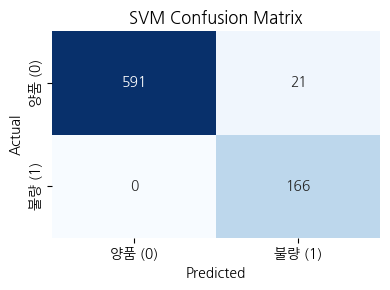

In [ ]:
# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = ['Average_Screw_RPM',
       'Cycle_Time', 'Clamp_Close_Time',
       'Barrel_Temperature_1',
        'Barrel_Temperature_6',
        'Mean_Mold_Temp',
       'Filling_Ratio',
       'Avg_Back_Pressure_Ratio',
        'Avg_Material_Temp',
        ]

X = rg3_aug[features]
y = rg3_aug[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# 🎯 SVM 모델 생성 및 훈련
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# 예측
y_pred_svm = svm_model.predict(X_test)

# 정확도 및 F1 점수 출력
print("🔹 SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("🔹 SVM F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))

# 분류 보고서 출력
print("🔹 SVM Report:\n", classification_report(y_test, y_pred_svm))

# 혼동 행렬 시각화
plot_conf_matrix(y_test, y_pred_xgb, title="SVM Confusion Matrix")

## XGB를 최종 모델로 선정

🔹 XGBoost Accuracy: 0.9730077120822622
🔹 XGBoost F1 Score: 0.9735750052979149
🔹 XGBoost Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98       612
           1       0.89      1.00      0.94       166

    accuracy                           0.97       778
   macro avg       0.94      0.98      0.96       778
weighted avg       0.98      0.97      0.97       778



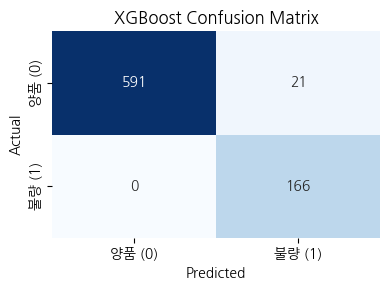

모델이 rg3_xgb_model.pkl으로 저장되었습니다.


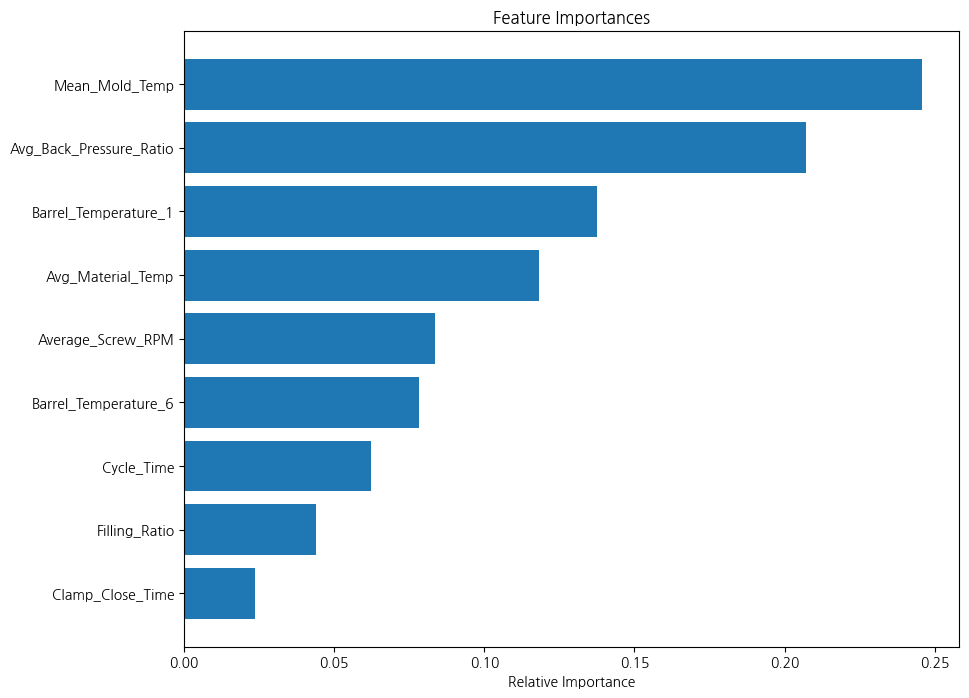


Feature Importances:
('Average_Screw_RPM', np.float64(0.08340750785759321))
('Cycle_Time', np.float64(0.06219994874653494))
('Clamp_Close_Time', np.float64(0.023618816069005663))
('Barrel_Temperature_1', np.float64(0.13736769896261108))
('Barrel_Temperature_6', np.float64(0.07821607650269498))
('Mean_Mold_Temp', np.float64(0.24589363189510202))
('Filling_Ratio', np.float64(0.044027821643936954))
('Avg_Back_Pressure_Ratio', np.float64(0.20714585199915203))
('Avg_Material_Temp', np.float64(0.11812264632336905))
✅ Train Accuracy: 0.8380
✅ Test Accuracy: 0.8290
과적합이 의심되지 않습니다.


In [ ]:
# 기존

# 🎯 타겟 변수 & 입력 변수 설정
target = "PassOrFail"
features = [ 'Average_Screw_RPM',
       'Cycle_Time', 'Clamp_Close_Time',
       'Barrel_Temperature_1',
        'Barrel_Temperature_6',
        'Mean_Mold_Temp',
       'Filling_Ratio',
       'Avg_Back_Pressure_Ratio',
        'Avg_Material_Temp',
        ]
X = rg3_aug[features]
y = rg3_aug[target]

# 데이터 분할 (훈련: 50%, 테스트: 50%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# XGBoost 모델 훈련
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, max_depth=5)
xgb_model.fit(X_train, y_train)

# 예측
y_pred_xgb = xgb_model.predict(X_test)

# 정확도 및 F1 점수 출력
print("🔹 XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("🔹 XGBoost F1 Score:", f1_score(y_test, y_pred_xgb, average='weighted'))

# 분류 보고서 출력
print("🔹 XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

# 혼동 행렬 시각화
plot_conf_matrix(y_test, y_pred_xgb, title="XGBoost Confusion Matrix")

# 피클 파일로 저장할 파일 경로 지정
file_name = 'rg3_xgb_model.pkl'

# 모델을 피클 파일로 저장
with open(file_name, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"모델이 {file_name}으로 저장되었습니다.")

# Feature Importance 시각화 및 출력
import matplotlib.pyplot as plt

feature_importances = rf_model.feature_importances_

# 중요도에 따라 feature를 정렬
indices = np.argsort(feature_importances)

# 가로 막대 그래프 생성
plt.figure(figsize=(10, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), feature_importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# Feature Importance 값 출력
print("\nFeature Importances:")
for feature in zip(features, rf_model.feature_importances_):
    print(feature)

train_acc = rf_model.score(X_train, y_train)  # 훈련 데이터 정확도
test_acc = rf_model.score(X_test, y_test)  # 테스트 데이터 정확도

print(f"✅ Train Accuracy: {train_acc:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")

# 과적합 여부 확인
if train_acc - test_acc > 0.1:  # 임계값 조정 가능
    print("과적합이 의심됩니다.")
else:
    print("과적합이 의심되지 않습니다.")

# 대시보드용 일별 불량수

In [ ]:
unlabeled_data = pd.read_csv("/content/unlabeled_data.csv")
unlabeled_data

,Unnamed: 0,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NO,PART_NAME,EQUIP_CD,EQUIP_NAME,ERR_FACT_QTY,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,0,5f9136166e37704af878240e,2020-01-02 00:59:22,2020-01-02 오전 12:00:00,2,87285Q5000,"SP2 CVR ROOF RACK CTR, RH",S01,1800TON-우진,11,...,0.0,0.0,0,0,0,0,0,0,0,0
1,1,5f9136166e37704af878240f,2020-01-02 01:01:01,2020-01-02 오전 12:00:00,1,87275Q5000,"SP2 CVR ROOF RACK CTR, LH",S01,1800TON-우진,11,...,0.0,0.0,0,0,0,0,0,0,0,0
2,2,5f9136166e37704af8782410,2020-01-02 01:01:01,2020-01-02 오전 12:00:00,2,87285Q5000,"SP2 CVR ROOF RACK CTR, RH",S01,1800TON-우진,11,...,0.0,0.0,0,0,0,0,0,0,0,0
3,3,5f9136166e37704af8782411,2020-01-02 01:02:24,2020-01-02 오전 12:00:00,1,87275Q5000,"SP2 CVR ROOF RACK CTR, LH",S01,1800TON-우진,11,...,0.0,0.0,0,0,0,0,0,0,0,0
4,4,5f9136166e37704af8782412,2020-01-02 01:02:24,2020-01-02 오전 12:00:00,2,87285Q5000,"SP2 CVR ROOF RACK CTR, RH",S01,1800TON-우진,11,...,0.0,0.0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795310,795310,5f926a806e37704af88455fb,2020-10-23 05:30:20,2020-10-23 오전 12:00:00,13,84721G9000,IK PNL C/PAD MAIN LHD,S10,3300TON-우진,0,...,0.0,0.0,0,0,0,0,0,0,0,0
795311,795311,5f926a806e37704af88455fc,2020-10-23 05:30:24,2020-10-23 오전 12:00:00,10,86141S8900,LX2 W/S SIDE MLD'G RH(RHD),S12,650톤-우진,0,...,20.2,23.6,0,0,0,0,0,0,0,0
795312,795312,5f926ab26e37704af88455fe,2020-10-23 05:31:13,2020-10-23 오전 12:00:00,1,87275Q5000,"SP2 CVR ROOF RACK CTR, LH",S01,1800TON-우진,2,...,0.0,0.0,0,0,0,0,0,0,0,0
795313,795313,5f926ab26e37704af88455ff,2020-10-23 05:31:13,2020-10-23 오전 12:00:00,2,87285Q5000,"SP2 CVR ROOF RACK CTR, RH",S01,1800TON-우진,2,...,0.0,0.0,0,0,0,0,0,0,0,0


In [ ]:
def del_column(data, machine_name, product_name):
    machine = data['EQUIP_NAME'] == machine_name
    product = data['PART_NAME'] == product_name
    data = data[machine & product]

    # 불필요하다고 판단되는 컬럼들 및 0이 많은 컬럼들 제거
    data = data.drop([ '_id', 'PART_FACT_SERIAL', 'PART_NO', 'EQUIP_CD', 'Barrel_Temperature_7', 'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_5',
                      'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8',
                      'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11',
                      'Mold_Temperature_12', 'Barrel_Temperature_7' ], axis=1)
    return data

In [ ]:
# 데이터 호기 종류
machine_name = '650톤-우진2호기'

# 데이터 제품 종류
product_name = ["CN7 W/S SIDE MLD'G LH", "CN7 W/S SIDE MLD'G RH",
                "RG3 MOLD'G W/SHLD, LH", "RG3 MOLD'G W/SHLD, RH"]

# '650톤-우진2호기'의 "CN7 W/S SIDE MLD'G LH" 데이터만 가져오기
cn7lh = del_column(unlabeled_data, machine_name, product_name[0])

# '650톤-우진2호기'의 "CN7 W/S SIDE MLD'G RH" 데이터만 가져오기
cn7rh = del_column(unlabeled_data, machine_name, product_name[1])

# '650톤-우진2호기'의 "RG3 MOLD'G W/SHLD, LH" 데이터만 가져오기
rg3lh = del_column(unlabeled_data, machine_name, product_name[2])

# '650톤-우진2호기'의 "RG3 MOLD'G W/SHLD, LH" 데이터만 가져오기
rg3rh = del_column(unlabeled_data, machine_name, product_name[3])

# 동일 제품의 LH와 RH 묶기
unlabeled_cn7 = pd.concat([cn7lh, cn7rh], ignore_index=True)
unlabeled_rg3 = pd.concat([rg3lh, rg3rh], ignore_index=True)

In [ ]:
# 데이터 저장
unlabeled_cn7.to_csv('unlabeled_cn7.csv', index=False)
unlabeled_rg3.to_csv('unlabeled_rg3.csv', index=False)

In [ ]:
cn7d = pd.read_csv("/content/unlabeled_cn7.csv")
cn7d

,Unnamed: 0,TimeStamp,PART_FACT_PLAN_DATE,PART_NAME,EQUIP_NAME,ERR_FACT_QTY,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,148671,2020-04-02 05:01:34,2020-04-01 오전 12:00:00,CN7 W/S SIDE MLD'G LH,650톤-우진2호기,96,10.11,2.99,16.52,68.21,...,14.3,271.5,275.5,275.1,270.6,264.5,240.1,59.1,24.8,26.6
1,149627,2020-04-02 07:56:32,2020-04-01 오전 12:00:00,CN7 W/S SIDE MLD'G LH,650톤-우진2호기,96,10.17,3.06,17.88,68.30,...,53.0,272.3,275.4,275.6,269.8,265.5,240.2,59.0,23.6,24.5
2,149994,2020-04-02 09:06:10,2020-04-01 오전 12:00:00,CN7 W/S SIDE MLD'G LH,650톤-우진2호기,96,10.11,2.99,17.61,68.17,...,53.3,271.7,274.7,274.8,269.4,265.3,239.9,59.2,23.3,27.5
3,150017,2020-04-02 09:10:44,2020-04-01 오전 12:00:00,CN7 W/S SIDE MLD'G LH,650톤-우진2호기,96,10.08,2.97,17.46,68.24,...,53.2,271.6,274.7,274.9,270.0,265.0,239.7,59.1,23.5,24.7
4,150169,2020-04-02 09:41:24,2020-04-01 오전 12:00:00,CN7 W/S SIDE MLD'G LH,650톤-우진2호기,96,10.09,2.97,17.59,68.20,...,53.2,270.5,274.6,274.5,270.1,264.4,240.0,59.2,23.3,28.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35234,777204,2020-10-20 06:16:15,2020-10-20 오전 12:00:00,CN7 W/S SIDE MLD'G RH,650톤-우진2호기,1,9.53,4.41,17.26,59.48,...,59.5,276.1,276.1,274.9,269.6,255.2,229.6,70.5,23.5,24.6
35235,777207,2020-10-20 06:17:15,2020-10-20 오전 12:00:00,CN7 W/S SIDE MLD'G RH,650톤-우진2호기,1,9.53,4.42,17.51,59.48,...,59.5,276.3,275.5,275.4,270.0,255.3,230.1,69.5,23.5,24.6
35236,777212,2020-10-20 06:18:16,2020-10-20 오전 12:00:00,CN7 W/S SIDE MLD'G RH,650톤-우진2호기,1,9.50,4.39,18.16,59.46,...,59.2,276.3,275.3,275.5,271.2,255.2,230.2,68.8,23.5,24.6
35237,777216,2020-10-20 06:19:14,2020-10-20 오전 12:00:00,CN7 W/S SIDE MLD'G RH,650톤-우진2호기,1,9.43,4.32,19.02,59.44,...,58.6,275.8,275.7,274.7,271.8,255.1,230.0,69.5,23.5,24.5


In [ ]:
# TimeStamp를 날짜 형식(YYYY-MM-DD)으로 변환
cn7d['TimeStamp'] = pd.to_datetime(cn7d['TimeStamp']).dt.date

# TimeStamp별 ERR_FACT_QTY 합산
cn7d_grouped = cn7d.groupby('TimeStamp', as_index=False)['ERR_FACT_QTY'].sum()

# 결과 확인
cn7d_grouped

,TimeStamp,ERR_FACT_QTY
0,2020-03-24,2568
1,2020-03-31,7238
2,2020-04-01,143528
3,2020-04-02,14396
4,2020-04-03,1302
5,2020-04-04,19890
6,2020-04-05,793
7,2020-04-06,203
8,2020-05-27,1282
9,2020-05-28,1068


In [ ]:
# 데이터 저장
cn7d_grouped.to_csv('cn7_grouped.csv', index=False)

In [ ]:
rg3d = pd.read_csv("/content/unlabeled_rg3.csv")
rg3d

,Unnamed: 0,TimeStamp,PART_FACT_PLAN_DATE,PART_NAME,EQUIP_NAME,ERR_FACT_QTY,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,119515,2020-03-25 23:56:49,2020-03-26 오전 12:00:00,"RG3 MOLD'G W/SHLD, LH",650톤-우진2호기,43,6.00,6.00,2.90,39.20,...,0.0,0.0,264.9,269.9,270.0,259.9,240.1,58.8,0.0,0.0
1,119547,2020-03-26 00:09:54,2020-03-26 오전 12:00:00,"RG3 MOLD'G W/SHLD, LH",650톤-우진2호기,43,6.00,6.00,2.90,39.20,...,0.0,0.0,264.8,269.8,269.9,259.8,240.0,59.0,0.0,0.0
2,119618,2020-03-26 00:36:05,2020-03-26 오전 12:00:00,"RG3 MOLD'G W/SHLD, LH",650톤-우진2호기,43,6.00,6.00,2.80,39.20,...,0.0,0.0,265.3,269.9,269.9,260.1,239.9,59.0,0.0,0.0
3,119781,2020-03-26 01:22:34,2020-03-26 오전 12:00:00,"RG3 MOLD'G W/SHLD, LH",650톤-우진2호기,43,6.00,6.00,2.90,39.20,...,0.0,0.0,264.8,269.9,269.8,259.8,239.7,59.2,0.0,0.0
4,120044,2020-03-26 02:44:22,2020-03-26 오전 12:00:00,"RG3 MOLD'G W/SHLD, LH",650톤-우진2호기,43,6.00,6.00,2.90,39.20,...,0.0,0.0,264.8,269.9,270.0,259.9,240.1,59.4,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35936,795288,2020-10-23 05:26:03,2020-10-23 오전 12:00:00,"RG3 MOLD'G W/SHLD, RH",650톤-우진2호기,0,1.06,0.94,12.88,61.78,...,60.8,285.6,284.7,284.2,274.5,265.5,235.5,64.9,23.2,24.7
35937,795293,2020-10-23 05:27:05,2020-10-23 오전 12:00:00,"RG3 MOLD'G W/SHLD, RH",650톤-우진2호기,0,1.06,0.94,12.88,61.78,...,61.0,285.8,285.6,285.0,274.1,265.5,234.8,65.0,23.2,24.7
35938,795299,2020-10-23 05:28:08,2020-10-23 오전 12:00:00,"RG3 MOLD'G W/SHLD, RH",650톤-우진2호기,0,1.06,0.94,12.93,61.78,...,61.2,286.9,284.6,285.4,274.5,266.0,234.7,64.9,23.2,24.7
35939,795304,2020-10-23 05:29:08,2020-10-23 오전 12:00:00,"RG3 MOLD'G W/SHLD, RH",650톤-우진2호기,0,1.06,0.94,12.90,61.78,...,61.5,286.5,285.6,285.3,275.7,265.0,235.1,64.9,23.3,24.7


In [ ]:
# TimeStamp를 날짜 형식(YYYY-MM-DD)으로 변환
rg3d['TimeStamp'] = pd.to_datetime(rg3d['TimeStamp']).dt.date

# TimeStamp별 ERR_FACT_QTY 합산
rg3d_grouped = rg3d.groupby('TimeStamp', as_index=False)['ERR_FACT_QTY'].sum()

# 결과 확인
rg3d_grouped

,TimeStamp,ERR_FACT_QTY
0,2020-03-25,43
1,2020-03-26,1080
2,2020-03-27,3894
3,2020-03-28,54339
4,2020-03-29,421514
5,2020-03-30,51722
6,2020-03-31,130083
7,2020-04-20,180
8,2020-04-21,873
9,2020-04-22,0


In [ ]:
# 데이터 저장
rg3d_grouped.to_csv('rg3_grouped.csv', index=False)